# Bank Fraud Detection — Data Preparation & Exploratory Analysis

## Phase 1

This notebook focuses on understanding, validating, exploring and preparing the credit card transaction dataset before developing machine learning and deep learning models.

The overall project will benchmark four levels of fraud detection approaches:

- **Tier 1 — Machine Learning**
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM

- **Tier 2 — Deep Learning for Tabular Data**
  - Multilayer Perceptron (MLP)
  - Autoencoder

- **Tier 3 — Temporal Deep Learning**
  - LSTM
  - GRU
  - 1D CNN

- **Tier 4 — Advanced Deep Learning**
  - Transformer
  - Graph Neural Network (GNN)

The primary objective is to compare these approaches using evaluation metrics that are appropriate for highly imbalanced fraud detection problems.

## 1. Project Context and Hypotheses

### 1.1 Business Problem

Financial fraud detection is a highly imbalanced binary classification problem.

In a real banking environment, fraudulent transactions represent only a small proportion of total transactions. Therefore, a model can achieve very high accuracy while failing to detect a significant proportion of fraudulent activity.

The objective of this project is to develop and benchmark multiple machine learning and deep learning approaches for identifying potentially fraudulent transactions.

The analysis will focus on:

- Fraud detection performance
- Precision and recall trade-offs
- Precision-Recall AUC (PR-AUC)
- False positives and false negatives
- Classification threshold optimisation
- Model complexity
- Training efficiency
- Business implications of model errors

### 1.2 Project Hypotheses

The project investigates whether increasingly sophisticated modeling approaches provide meaningful improvements over traditional machine learning methods for fraud detection.

The main hypotheses are:

1. Gradient boosting models will provide strong performance on tabular transaction data.
2. Deep learning models may capture additional non-linear relationships between transaction features.
3. Temporal models may benefit from transaction sequences and behavioural patterns.
4. Transformer-based architectures may capture long-range dependencies in transaction sequences.
5. Graph Neural Networks may provide additional value when relationships between customers, accounts, devices and merchants are explicitly represented as a graph.

These hypotheses will be evaluated empirically rather than assumed to be true.

## 2. Project Setup

### 2.1 Imports and Environment

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Pandas Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# Seaborn Configuration

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [3]:
# Print Library Versions
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.5.3
Pandas version: 3.0.5


### 2.2 Project Paths

Paths are resolved from the project root so notebooks can be opened from the repository root or the notebooks directory.

In [4]:
# Resolve the project root whether Jupyter starts in the repository or notebooks/.
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir()
    ),
    Path.cwd(),
)
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "creditcard.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Processed data path:", PROCESSED_DATA_PATH)

Project root: /home/anderjcruz/projects/Bank-Fraud-Detection
Raw data path: /home/anderjcruz/projects/Bank-Fraud-Detection/data/raw/creditcard.csv
Processed data path: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed


In [5]:
# Validate the file

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {RAW_DATA_PATH.resolve()}"
    )

print(f"Dataset found: {RAW_DATA_PATH.resolve()}")

Dataset found: /home/anderjcruz/projects/Bank-Fraud-Detection/data/raw/creditcard.csv


## 3. Dataset Loading

The dataset used in this project is the Credit Card Fraud Detection dataset provided by the Machine Learning Group of ULB.

The dataset contains anonymised credit card transactions and a binary target variable indicating whether a transaction is fraudulent.

The original dataset contains approximately 285,000 transactions, with fraud representing a very small proportion of all observations.

In [6]:
df = pd.read_csv(RAW_DATA_PATH)

In [7]:
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (284807, 31)


In [8]:
# Display the first few rows of the dataset

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [10]:
# Display the shape of the dataset

rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns:,}")

Rows: 284,807
Columns: 31


In [11]:
# Display the column names of the dataset
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


### 3.1 Dataset Overview

The first step after loading the data is to understand its basic structure.

We will inspect:

- Number of observations
- Number of features
- Column names
- Data types
- Summary statistics

This provides the foundation for the subsequent data quality and exploratory analysis.

In [12]:
# Display the data types of each column in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### 3.2 Target Variable

In [14]:
TARGET = "Class"

print(f"Target variable: {TARGET}")
print(f"Target data type: {df[TARGET].dtype}")
print(f"Unique target values: {df[TARGET].unique()}")

Target variable: Class
Target data type: int64
Unique target values: [0 1]


### 3.3 Problem Type

In [15]:
unique_target_values = df[TARGET].nunique()

print(f"Number of unique target values: {unique_target_values}")

Number of unique target values: 2


## 4. Data Quality Assessment

The checks cover missing values, duplicate records, and infinite numeric values. Duplicate records are investigated separately before deciding whether to remove them.

### 4.1 Missing, Duplicate, and Infinite Value Checks

In [16]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [17]:
print(f"Total missing values: {df.isnull().sum().sum():,}")

Total missing values: 0


In [18]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 1,081


In [19]:
infinite_count = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

print(f"Infinite values: {infinite_count:,}")

Infinite values: 0


### 4.2 Duplicate Record Investigation

The dataset contains duplicate rows. Before removing them, we need to determine whether duplicated observations are associated with legitimate or fraudulent transactions.

Removing duplicates without investigation could alter the class distribution and potentially remove meaningful observations.

Therefore, duplicates will be analysed before any cleaning decision is made.

In [20]:
duplicate_mask = df.duplicated(keep=False)

duplicate_data = df.loc[duplicate_mask]

print(f"Rows belonging to duplicated groups: {len(duplicate_data):,}")

Rows belonging to duplicated groups: 1,854


In [21]:
duplicate_class_distribution = (
    duplicate_data[TARGET]
    .value_counts()
    .sort_index()
)

duplicate_class_distribution

Class
0    1822
1      32
Name: count, dtype: int64

In [22]:
duplicate_class_percentage = (
    duplicate_data[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

duplicate_class_percentage

Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64

## 5. Target Distribution

Fraud detection is typically characterised by severe class imbalance.

A small proportion of transactions are fraudulent compared with legitimate transactions.

Understanding the class distribution is critical because conventional accuracy can become misleading in highly imbalanced classification problems.

In [23]:
class_counts = df[TARGET].value_counts().sort_index()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [24]:
class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100
})

class_distribution

,count,percentage
Class,,
0,284315,99.827251
1,492,0.172749


## 6. Exploratory Data Analysis

### 6.1 Transaction Amount and Amount_log Feature Engineering

In [25]:
df["Amount_log"] = np.log1p(df["Amount"])

In [26]:
df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [27]:
print(f"Original Amount skewness: {df['Amount'].skew():.4f}")
print(f"Log-transformed Amount skewness: {df['Amount_log'].skew():.4f}")

Original Amount skewness: 16.9777
Log-transformed Amount skewness: 0.1627


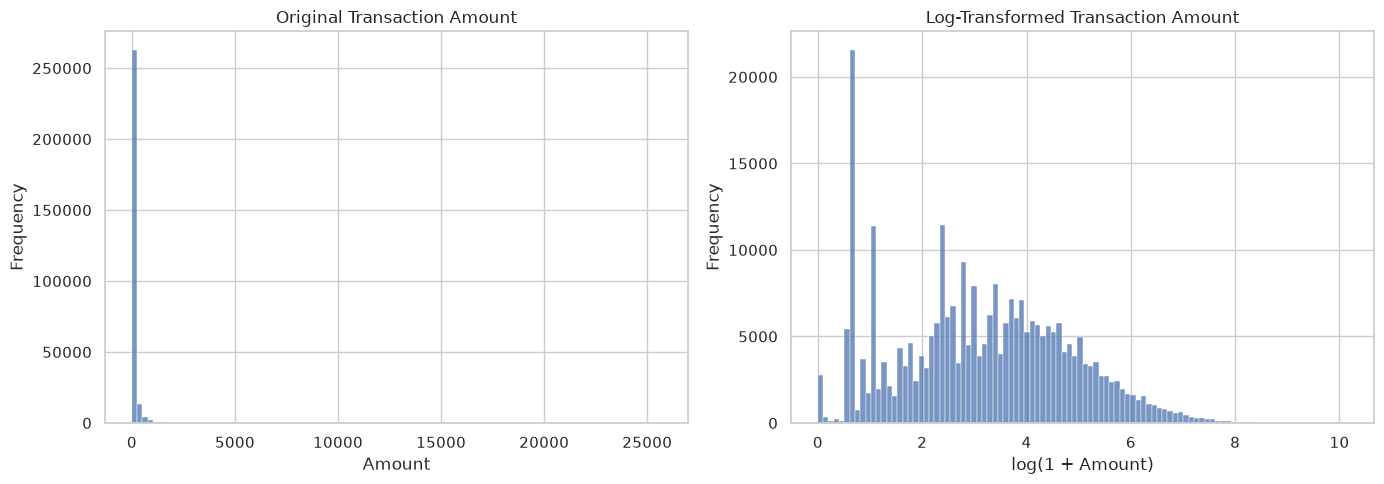

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100,
    ax=axes[0]
)

axes[0].set_title("Original Transaction Amount")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")

sns.histplot(
    data=df,
    x="Amount_log",
    bins=100,
    ax=axes[1]
)

axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 6.1.1 Transaction Amount by Class — Full-Dataset Descriptive EDA

These full-dataset comparisons describe how observed transaction amounts vary by `Class`. They are exploratory only and are not used as feature-selection evidence.


In [29]:
amount_by_class = (
    df.groupby(TARGET)["Amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

amount_by_class

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


In [30]:
amount_quantiles = (
    df.groupby(TARGET)["Amount"]
    .quantile([0.25, 0.50, 0.75, 0.95, 0.99])
    .unstack()
)

amount_quantiles

,0.25,0.50,0.75,0.95,0.99
Class,,,,,
0,5.65,22.00,77.05,364.409,1016.9664
1,1.00,9.25,105.89,640.905,1357.4279


#### 6.1.2 Transaction Amount by Class — Log Scale (Full-Dataset Descriptive EDA)

These full-dataset class comparisons remain descriptive EDA only. They do not determine whether `Amount` or `Amount_log` is retained as a modeling candidate.


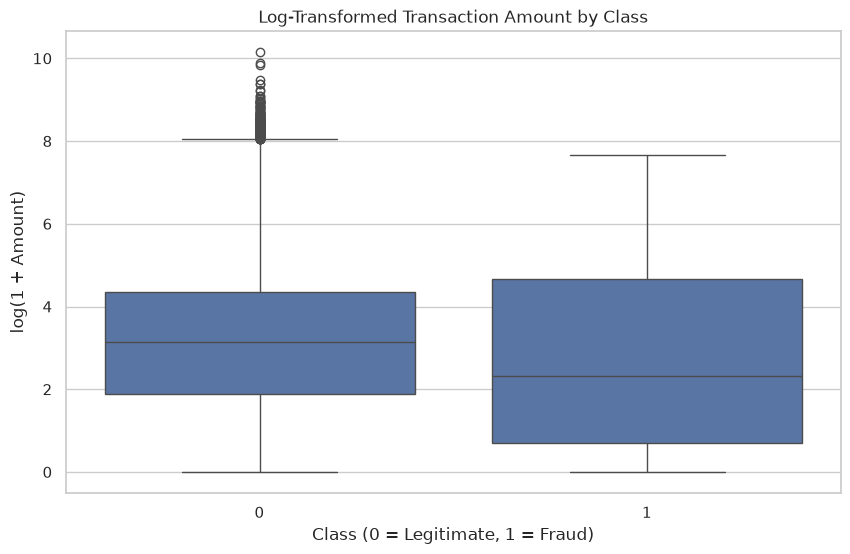

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET,
    y="Amount_log"
)

plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("log(1 + Amount)")

plt.show()

#### 6.1.3 Amount EDA Finding

The full-dataset summaries show that the transaction amount distributions differ between legitimate and fraudulent transactions. Although fraudulent transactions have a higher mean transaction amount, their median is lower, indicating skewed distributions in which a small number of higher-value transactions influence the mean.

The full-dataset `Amount` and `Amount_log` plots and class comparisons are descriptive EDA only. They are not used to decide whether either feature is retained. The label-informed candidate decision uses the chronological training portion only, as documented in Section 8.1.2.

The `log1p` transformation substantially reduces the skewness of `Amount` in this descriptive analysis. Its deterministic calculation does not use the target.


### 6.2 Time Analysis

The `Time` variable represents the elapsed time, in seconds, since the first transaction recorded in the dataset.

This variable provides temporal information that may be relevant for sequential modeling in later phases.

In [32]:
time_stats = df["Time"].describe()

time_stats

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [33]:
df["Time_hours"] = df["Time"] / 3600

In [34]:
print(f"Time range: {df['Time_hours'].min():.2f} to {df['Time_hours'].max():.2f} hours")

Time range: 0.00 to 48.00 hours


In [35]:
is_time_sorted = df["Time"].is_monotonic_increasing

print(f"Transactions are chronologically ordered: {is_time_sorted}")

Transactions are chronologically ordered: True


In [36]:
time_unique = df["Time"].nunique()
time_total = len(df)

print(f"Total transactions: {time_total:,}")
print(f"Unique Time values: {time_unique:,}")
print(f"Transactions sharing a Time value: {time_total - time_unique:,}")

Total transactions: 284,807
Unique Time values: 124,592
Transactions sharing a Time value: 160,215


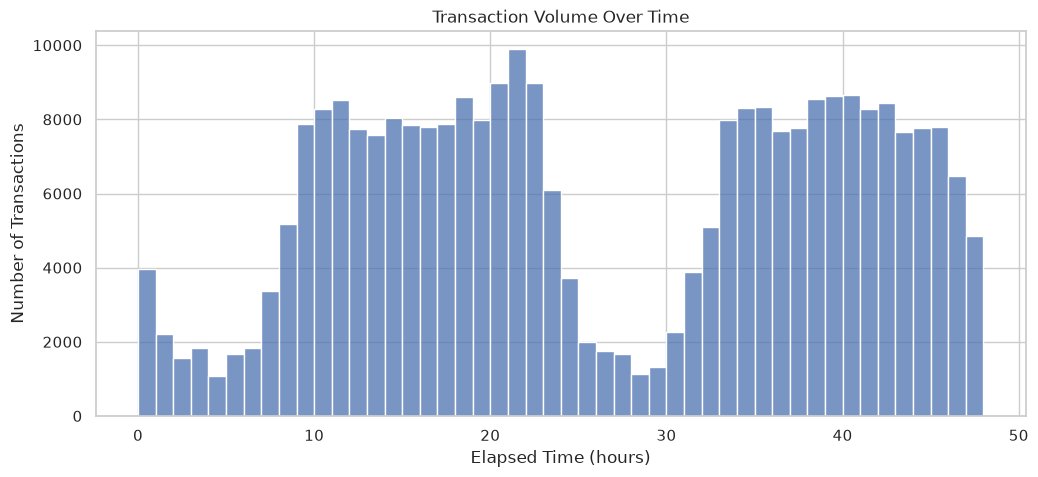

In [37]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time_hours",
    bins=48
)

plt.title("Transaction Volume Over Time")
plt.xlabel("Elapsed Time (hours)")
plt.ylabel("Number of Transactions")

plt.show()

In [38]:
time_by_class = (
    df.groupby(TARGET)["Time_hours"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

time_by_class

,count,mean,median,min,max
Class,,,,,
0,284315,26.343945,23.530833,0.000000,47.997778
1,492,22.429669,20.991250,0.112778,47.318889


#### 6.2.1 Full-Dataset Fraud Rate Over Time

In [39]:
time_bins = pd.cut(
    df["Time_hours"],
    bins=48
)

df["Time_bin"] = time_bins

In [40]:
fraud_rate_over_time = (
    df.groupby("Time_bin", observed=True)[TARGET]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

fraud_rate_over_time.head()

,transactions,fraud_count,fraud_rate
Time_bin,,,
"(-0.048, 1.0]",3963,2,0.000505
"(1.0, 2.0]",2217,2,0.000902
"(2.0, 3.0]",1576,21,0.013325
"(3.0, 4.0]",1821,13,0.007139
"(4.0, 5.0]",1082,6,0.005545


In [41]:
fraud_rate_over_time["fraud_rate_pct"] = (
    fraud_rate_over_time["fraud_rate"] * 100
)

In [42]:
fraud_rate_over_time.head()

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(-0.048, 1.0]",3963,2,0.000505,0.050467
"(1.0, 2.0]",2217,2,0.000902,0.090212
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(3.0, 4.0]",1821,13,0.007139,0.713893
"(4.0, 5.0]",1082,6,0.005545,0.554529


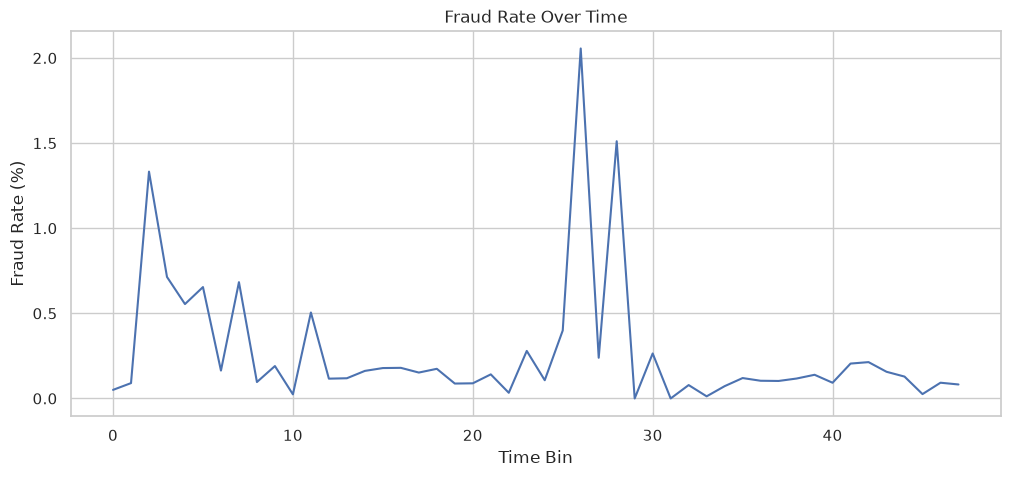

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(fraud_rate_over_time)),
    fraud_rate_over_time["fraud_rate_pct"]
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Time Bin")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [44]:
top_fraud_rate_bins = (
    fraud_rate_over_time
    .sort_values("fraud_rate", ascending=False)
    .head(10)
)

top_fraud_rate_bins

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(25.999, 26.999]",1751,36,0.020560,2.055968
"(27.999, 28.999]",1125,17,0.015111,1.511111
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(3.0, 4.0]",1821,13,0.007139,0.713893
"(7.0, 8.0]",3366,23,0.006833,0.683304
"(5.0, 6.0]",1681,11,0.006544,0.654372
"(4.0, 5.0]",1082,6,0.005545,0.554529
"(10.999, 11.999]",8514,43,0.005051,0.505051
"(24.999, 25.999]",2003,8,0.003994,0.399401


In [45]:
top_fraud_count_bins = (
    fraud_rate_over_time
    .sort_values("fraud_count", ascending=False)
    .head(10)
)

In [46]:
top_fraud_count_bins

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_bin,,,,
"(10.999, 11.999]",8514,43,0.005051,0.505051
"(25.999, 26.999]",1751,36,0.020560,2.055968
"(7.0, 8.0]",3366,23,0.006833,0.683304
"(2.0, 3.0]",1576,21,0.013325,1.332487
"(41.998, 42.998]",8431,18,0.002135,0.213498
"(27.999, 28.999]",1125,17,0.015111,1.511111
"(22.999, 23.999]",6087,17,0.002793,0.279284
"(40.998, 41.998]",8293,17,0.002050,0.204992
"(17.999, 18.999]",8608,15,0.001743,0.174257


##### Full-Dataset Temporal EDA Finding

This full-dataset temporal summary is descriptive EDA only. It is not used to select `Time_hour` or another modeling feature.

#### 6.2.2 Deterministic Time_hour and Training-Only Candidate Analysis

In [47]:
df["Time_hour"] = np.floor(df["Time_hours"]).astype(int)

In [48]:
# Use only the first 70% of chronological observations for label-informed feature analysis.
# This boundary matches the training portion of the later 70/15/15 split.
train_end_for_feature_selection = int(len(df) * 0.70)
feature_selection_train_df = df.iloc[:train_end_for_feature_selection].copy()

fraud_by_hour = (
    feature_selection_train_df.groupby("Time_hour")[TARGET]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)


In [49]:
fraud_by_hour["fraud_rate_pct"] = (
    fraud_by_hour["fraud_rate"] * 100
)

In [50]:
fraud_by_hour.head()

,transactions,fraud_count,fraud_rate,fraud_rate_pct
Time_hour,,,,
0,3963,2,0.000505,0.050467
1,2217,2,0.000902,0.090212
2,1576,21,0.013325,1.332487
3,1821,13,0.007139,0.713893
4,1082,6,0.005545,0.554529


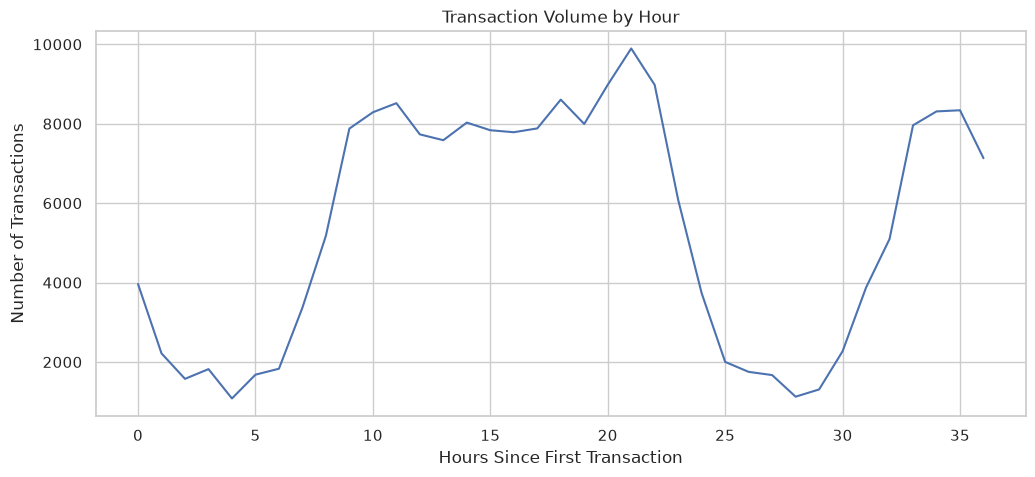

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["transactions"]
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Number of Transactions")

plt.show()

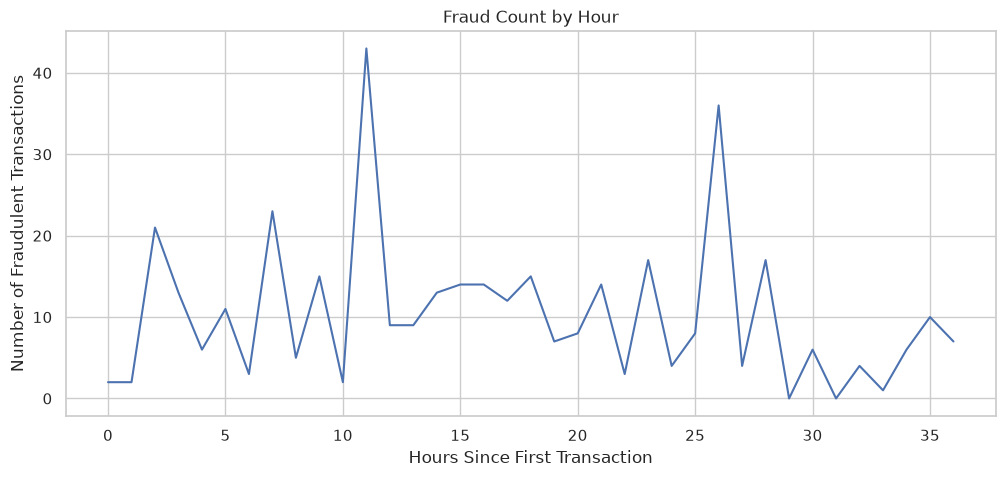

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["fraud_count"]
)

plt.title("Fraud Count by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

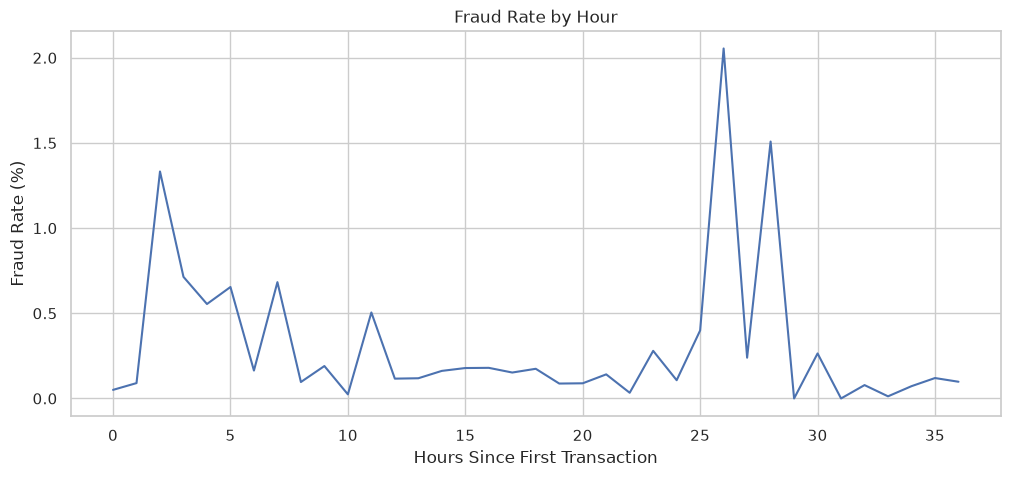

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour["fraud_rate_pct"]
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hours Since First Transaction")
plt.ylabel("Fraud Rate (%)")

plt.show()

##### Training-Only Hourly Analysis Finding

Transaction activity, fraud counts, and fraud rates vary across hours in the training period. The charts above use only the first 70% of chronologically ordered observations, matching the training portion of the later split.

These training-only patterns support keeping `Time_hour` as a candidate feature. The data covers only about two days and does not provide customer, account, merchant, or device identifiers, so the patterns are dataset-specific and should not be treated as general behavioral rules. Validation and test labels are not used in this feature-selection decision.

## 7. Feature Analysis

### 7.1 PCA Feature Distributions and Summary Statistics

In [54]:
# Define PCA features
PCA_FEATURES = [f"V{i}" for i in range(1, 29)]

print(f"Number of PCA features: {len(PCA_FEATURES)}")
print(PCA_FEATURES)

Number of PCA features: 28
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [55]:
# Explore PCA feature distributions
pca_summary = df[PCA_FEATURES].describe().T

pca_summary

,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995
V10,284807.0,2.238554e-15,1.088850,-24.588262,-0.535426,-0.092917,0.453923,23.745136


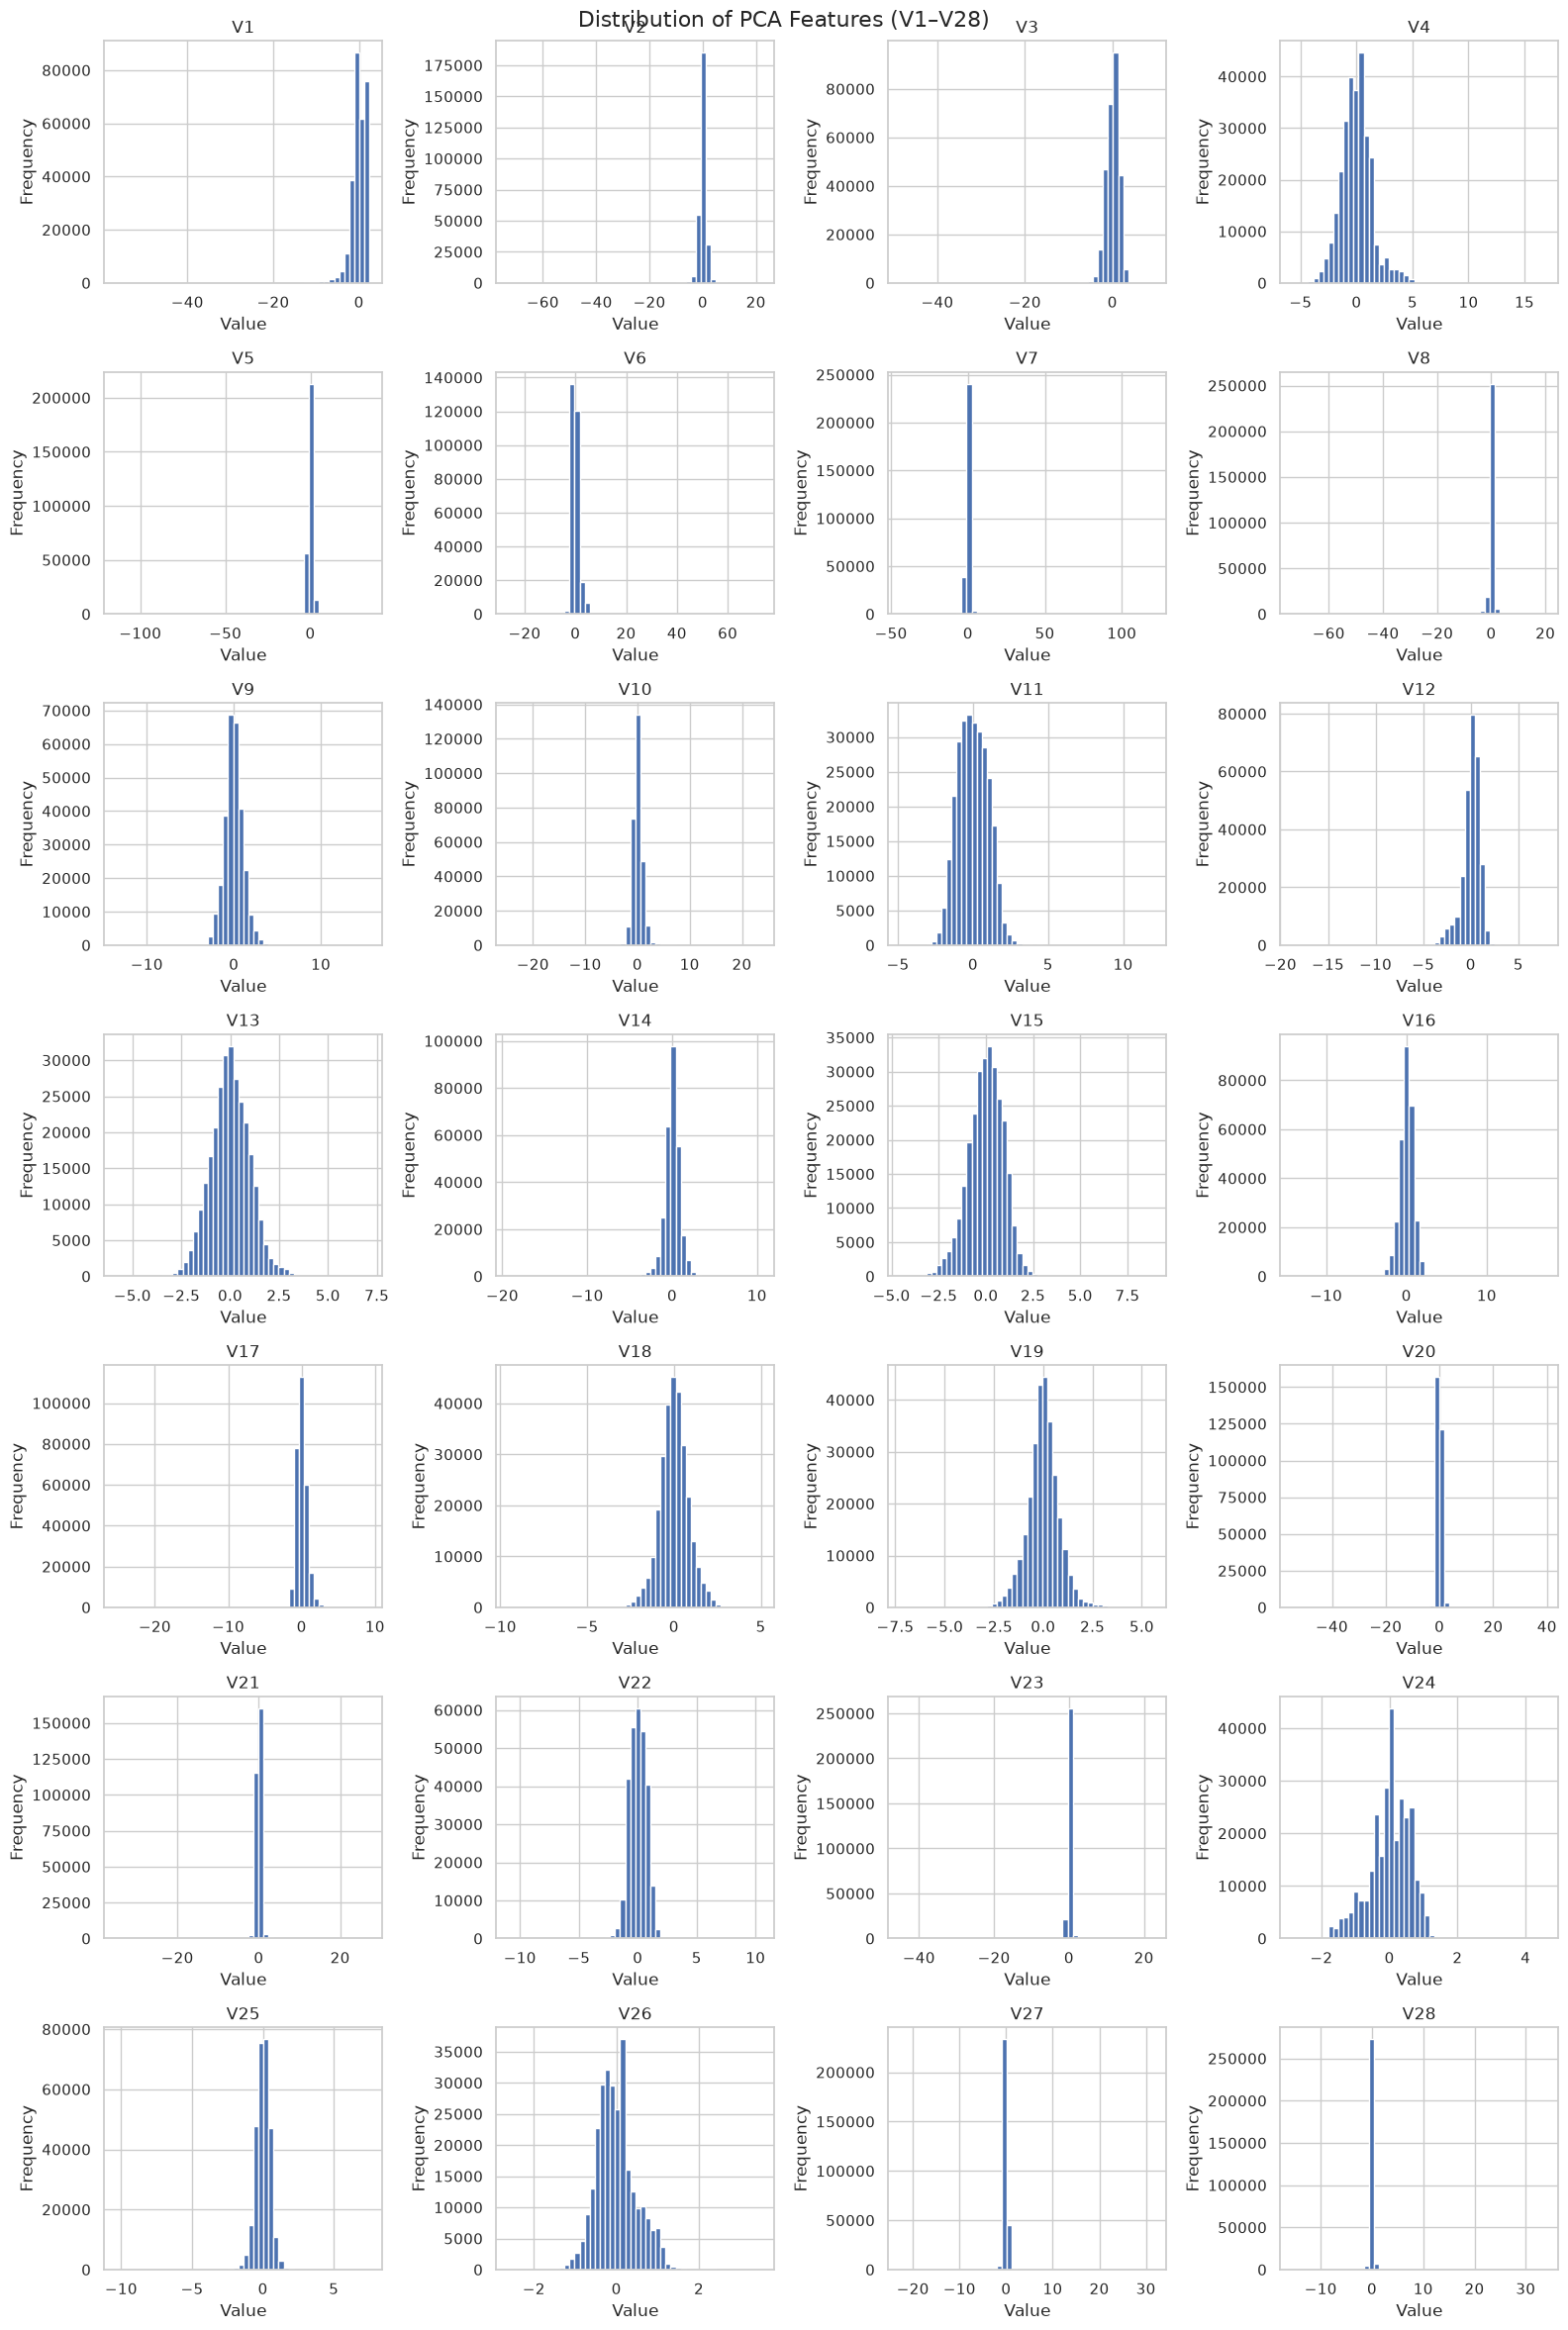

In [56]:
# Explore PCA feature distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(7, 4, figsize=(16, 24))

for ax, feature in zip(axes.ravel(), PCA_FEATURES):
    ax.hist(df[feature], bins=50)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of PCA Features (V1–V28)", fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
# Explore PCA feature distributions
pca_skewness = df[PCA_FEATURES].skew().sort_values()

pca_skewness

V8     -8.521944
V23    -5.875140
V2     -4.624866
V17    -3.844914
V1     -3.280667
V5     -2.425901
V12    -2.278401
V3     -2.240155
V20    -2.037155
V14    -1.995176
V27    -1.170209
V16    -1.100966
V24    -0.552499
V25    -0.415793
V15    -0.308423
V18    -0.259880
V22    -0.213258
V13     0.065233
V19     0.109192
V11     0.356506
V9      0.554680
V26     0.576693
V4      0.676292
V10     1.187141
V6      1.826581
V7      2.553907
V21     3.592991
V28    11.192091
dtype: float64

In [58]:
# Explore PCA feature distributions
pca_distribution_stats = pd.DataFrame({
    "skewness": df[PCA_FEATURES].skew(),
    "kurtosis": df[PCA_FEATURES].kurt()
})

pca_distribution_stats["abs_skewness"] = (
    pca_distribution_stats["skewness"].abs()
)

pca_distribution_stats = pca_distribution_stats.sort_values(
    "abs_skewness",
    ascending=False
)

pca_distribution_stats

,skewness,kurtosis,abs_skewness
V28,11.192091,933.397502,11.192091
V8,-8.521944,220.586974,8.521944
V23,-5.875140,440.088659,5.875140
V2,-4.624866,95.773106,4.624866
V17,-3.844914,94.799719,3.844914
V21,3.592991,207.287040,3.592991
V1,-3.280667,32.486679,3.280667
V7,2.553907,405.607417,2.553907
V5,-2.425901,206.904560,2.425901
V12,-2.278401,20.241870,2.278401


In [59]:
# Explore PCA feature distributions    
df.groupby("Class")["V1"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,0.008258,1.929814,-56.40751,-0.917544,0.020023,1.316218,2.454930
1,492.0,-4.771948,6.783687,-30.55238,-6.036063,-2.342497,-0.419200,2.132386


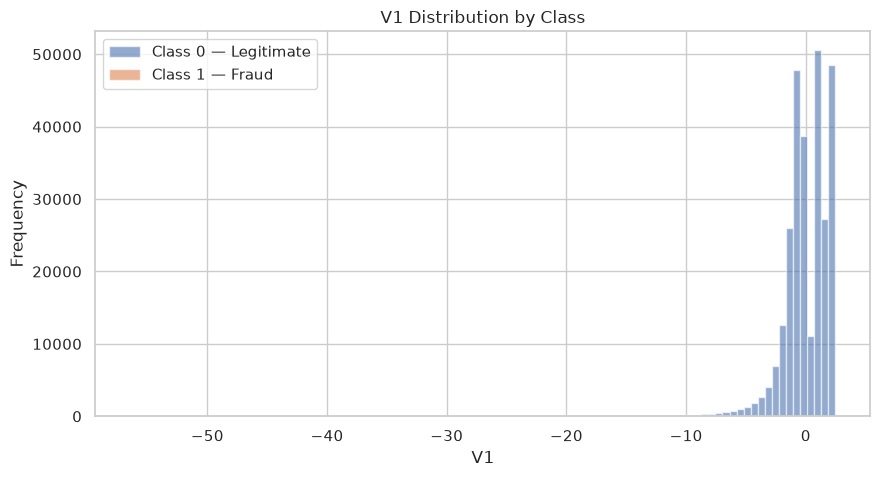

In [60]:
# Select the V1 values for each target class.
legitimate_v1 = df.loc[df["Class"] == 0, "V1"]
fraud_v1 = df.loc[df["Class"] == 1, "V1"]

# Plot both distributions using the same bins
# so that their shapes can be compared on the same scale.
plt.figure(figsize=(10, 5))

plt.hist(
    legitimate_v1,
    bins=100,
    alpha=0.6,
    label="Class 0 — Legitimate"
)

plt.hist(
    fraud_v1,
    bins=100,
    alpha=0.6,
    label="Class 1 — Fraud"
)

# Add labels and title to make the comparison self-explanatory.
plt.title("V1 Distribution by Class")
plt.xlabel("V1")
plt.ylabel("Frequency")
plt.legend()

# Display the chart.
plt.show()

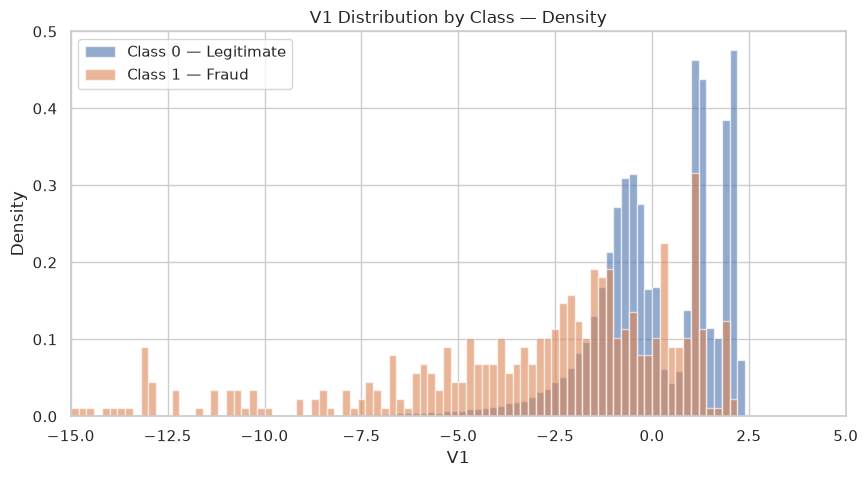

In [61]:
# Define common bin edges so that both classes are evaluated
# over exactly the same intervals.
common_bins = np.linspace(-15, 5, 101)

# Plot both class distributions using the same bins and density scale.
plt.figure(figsize=(10, 5))

plt.hist(
    legitimate_v1,
    bins=common_bins,
    density=True,
    alpha=0.6,
    label="Class 0 — Legitimate"
)

plt.hist(
    fraud_v1,
    bins=common_bins,
    density=True,
    alpha=0.6,
    label="Class 1 — Fraud"
)

# Keep the focus on the main distribution range.
plt.xlim(-15, 5)

# Add labels and title.
plt.title("V1 Distribution by Class — Density")
plt.xlabel("V1")
plt.ylabel("Density")
plt.legend()

# Display the chart.
plt.show()

In [62]:
# Calculate the median of each PCA feature separately for legitimate
# and fraudulent transactions.
pca_class_medians = df.groupby("Class")[PCA_FEATURES].median().T

# Rename the columns to make the class meaning explicit.
pca_class_medians.columns = [
    "legitimate_median",
    "fraud_median"
]

# Calculate the difference between the fraud and legitimate medians.
pca_class_medians["median_difference"] = (
    pca_class_medians["fraud_median"]
    - pca_class_medians["legitimate_median"]
)

# Sort by the absolute size of the median difference
# to identify features with the largest distributional shift.
pca_class_medians["abs_median_difference"] = (
    pca_class_medians["median_difference"].abs()
)

pca_class_medians = pca_class_medians.sort_values(
    "abs_median_difference",
    ascending=False
)

pca_class_medians

,legitimate_median,fraud_median,median_difference,abs_median_difference
V14,0.051947,-6.729720,-6.781667,6.781667
V12,0.141679,-5.502530,-5.644208,5.644208
V3,0.182158,-5.075257,-5.257415,5.257415
V17,-0.064833,-5.302949,-5.238115,5.238115
V10,-0.091872,-4.578825,-4.486953,4.486953
V4,-0.022405,4.177147,4.199552,4.199552
V11,-0.034923,3.586218,3.621142,3.621142
V16,0.067377,-3.549795,-3.617172,3.617172
V7,0.041138,-3.034402,-3.075540,3.075540
V2,0.064070,2.717869,2.653799,2.653799


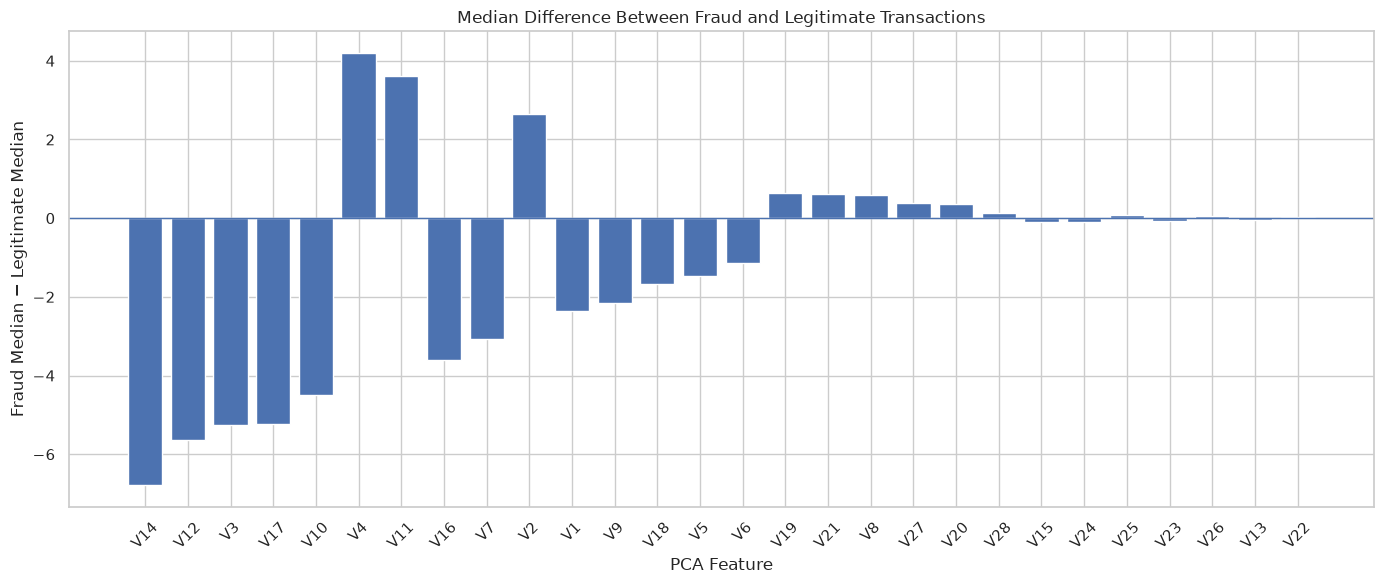

In [63]:
# Create a bar chart showing the difference between fraud and legitimate
# medians for all PCA features.
plt.figure(figsize=(14, 6))

plt.bar(
    pca_class_medians.index,
    pca_class_medians["median_difference"]
)

# Add a horizontal reference line at zero.
# This separates features where the fraud median is higher or lower.
plt.axhline(0, linewidth=1)

# Add labels and title.
plt.title("Median Difference Between Fraud and Legitimate Transactions")
plt.xlabel("PCA Feature")
plt.ylabel("Fraud Median − Legitimate Median")

# Rotate feature names slightly for readability.
plt.xticks(rotation=45)

# Adjust the layout to prevent labels from being cut off.
plt.tight_layout()

# Display the chart.
plt.show()

**Conclusion:** Algumas PCA components exhibit substantial distributional shifts between legitimate and fraudulent transactions, particularly V14, V12, V3, V17, V10, V4, and V11. Other components show much smaller differences in their central tendency. These observations are exploratory and do not by themselves establish predictive importance.

In [64]:
# Select the eight PCA features with the largest absolute
# difference in median between the two classes.
TOP_MEDIAN_SHIFT_FEATURES = (
    pca_class_medians
    .head(8)
    .index
    .tolist()
)

# Calculate the standard deviation for each selected feature
# separately for legitimate and fraudulent transactions.
pca_class_std = df.groupby("Class")[TOP_MEDIAN_SHIFT_FEATURES].std().T

# Rename the columns to make the class meaning explicit.
pca_class_std.columns = [
    "legitimate_std",
    "fraud_std"
]

# Display the standard deviations for comparison.
pca_class_std

,legitimate_std,fraud_std
V14,0.897007,4.278940
V12,0.945939,4.654458
V3,1.459429,7.110937
V17,0.749457,6.970618
V10,1.044204,4.897341
V4,1.399333,2.873318
V11,1.003112,2.678605
V16,0.844772,3.865035


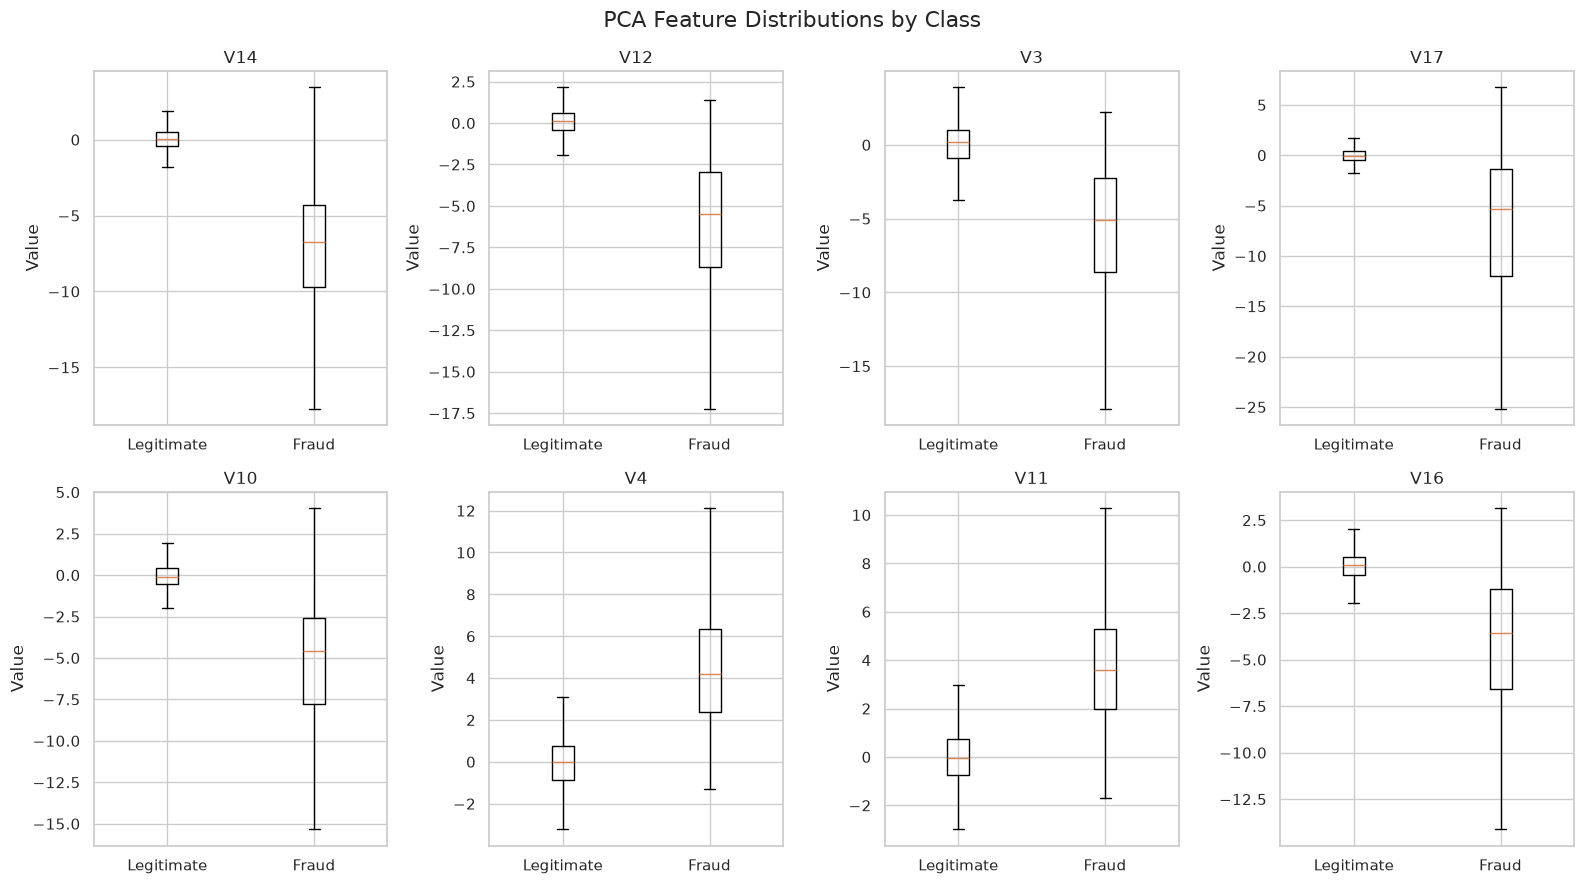

In [65]:
# Create a figure containing one boxplot for each of the selected PCA features.
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

# Iterate through the selected features and corresponding subplot axes.
for ax, feature in zip(axes.ravel(), TOP_MEDIAN_SHIFT_FEATURES):

    # Create separate distributions for legitimate and fraudulent transactions.
    data_to_plot = [
        df.loc[df["Class"] == 0, feature],
        df.loc[df["Class"] == 1, feature]
    ]

    # Plot the two class distributions side by side.
    # tick_labels is used by the installed Matplotlib version.
    ax.boxplot(
        data_to_plot,
        tick_labels=["Legitimate", "Fraud"],
        showfliers=False
    )

    # Add the feature name and axis labels.
    ax.set_title(feature)
    ax.set_ylabel("Value")

# Add an overall title to the figure.
fig.suptitle(
    "PCA Feature Distributions by Class",
    fontsize=16
)

# Adjust spacing between subplots.
plt.tight_layout()

# Display the figure.
plt.show()

### 7.2 PCA Feature Distributions by Class

The PCA-derived features exhibit heterogeneous distributions across the dataset. Several components show substantial skewness and heavy tails, with particularly extreme distributions observed for features such as V28, V8, V23, V7, and V20.

The distributions also differ substantially between legitimate and fraudulent transactions. Several PCA components, including V14, V12, V3, V17, V10, V4, V11, and V16, show pronounced shifts in their central tendency and dispersion between the two classes.

These differences indicate that the PCA features contain potentially informative distributional patterns for fraud detection. However, descriptive statistics and visual comparisons alone do not establish predictive importance. Feature importance and predictive contribution will be evaluated later through model-based analysis using appropriate validation procedures and metrics.

Extreme values were observed in several PCA components. These observations were not removed or transformed at this stage because extreme values may contain relevant information for fraud detection. Outlier treatment will be investigated separately in Section 7.4.

No feature selection or transformation was performed based solely on the exploratory distribution analysis.

### 7.3 Correlation Analysis

In [66]:
# Calculate the Pearson correlation matrix among the PCA-derived features.
# This allows us to verify how strongly the PCA components are linearly related.
pca_correlation = df[PCA_FEATURES].corr()

# Display the correlation matrix.
pca_correlation

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
V1,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,7.388135e-17,2.125498e-16,2.053457e-16,-2.425603e-17,-5.020280e-16,3.547782e-16,7.212815e-17,-3.879840e-16,3.230206e-17,1.502024e-16,4.654551e-16,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15
V2,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,-3.991394e-16,1.975426e-16,-9.568710e-17,6.295388e-16,-1.730566e-16,-4.995814e-17,1.177316e-17,-2.685296e-16,3.284605e-16,-7.118719e-18,2.506675e-16,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16
V3,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,1.156587e-15,1.576830e-15,6.310231e-16,2.807652e-16,4.739859e-16,9.068793e-16,8.299445e-16,7.614712e-16,1.509897e-16,3.463522e-16,-9.316409e-16,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16
V4,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,2.232685e-16,3.459380e-16,-5.625518e-16,1.303306e-16,2.282280e-16,1.377649e-16,-9.614528e-16,-2.699612e-16,-5.103644e-16,-3.980557e-16,-1.857247e-16,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18
V5,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,-5.202306e-16,7.203963e-16,7.412552e-16,5.886991e-16,6.565143e-16,-8.720275e-16,2.246261e-15,1.281914e-16,5.308590e-16,-1.450421e-16,-3.554057e-16,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18
V6,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,5.932243e-17,1.980503e-15,2.375468e-16,-1.211182e-16,2.621312e-16,-1.531188e-15,2.623672e-18,2.015618e-16,1.223814e-16,-1.865597e-16,-1.858755e-16,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16
V7,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,-7.492834e-17,1.425248e-16,-3.536655e-18,1.266462e-17,2.607772e-16,-1.690540e-16,5.869302e-17,2.177192e-16,7.604126e-17,-1.881008e-16,9.379684e-16,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16
V8,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,-2.801370e-16,2.487043e-16,1.839891e-16,-2.921856e-16,-8.599156e-16,4.127777e-16,-5.254741e-16,-2.269549e-16,-3.667974e-16,-3.875186e-16,2.033737e-16,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16
V9,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,-4.642274e-16,1.354680e-16,-1.079314e-15,2.251072e-15,3.784757e-15,-1.051167e-15,-1.214086e-15,1.113695e-15,4.993240e-16,-1.376135e-16,-2.343720e-16,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15
V10,7.388135e-17,-3.991394e-16,1.156587e-15,2.232685e-16,-5.202306e-16,5.932243e-17,-7.492834e-17,-2.801370e-16,-4.642274e-16,1.000000e+00,-4.622103e-16,1.771869e-15,-5.418460e-16,2.635936e-16,5.786332e-16,3.545450e-16,1.542955e-15,3.902423e-16,3.437633e-17,-1.331556e-15,1.177547e-15,-6.418202e-16,3.214491e-16,-1.355885e-16,-2.846052e-16,-3.028119e-16,-2.197977e-16,4.864782e-17


In [67]:
# Calculate the Pearson correlation between each PCA feature and the target variable.
# This measures the strength and direction of the linear association with fraud.
feature_class_correlation = (
    df[PCA_FEATURES + ["Class"]]
    .corr()["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

# Display the correlations ordered by absolute strength.
feature_class_correlation

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
V21    0.040413
V19    0.034783
V20    0.020090
V8     0.019875
V27    0.017580
V28    0.009536
V24   -0.007221
V13   -0.004570
V26    0.004455
V15   -0.004223
V25    0.003308
V23   -0.002685
V22    0.000805
Name: Class, dtype: float64

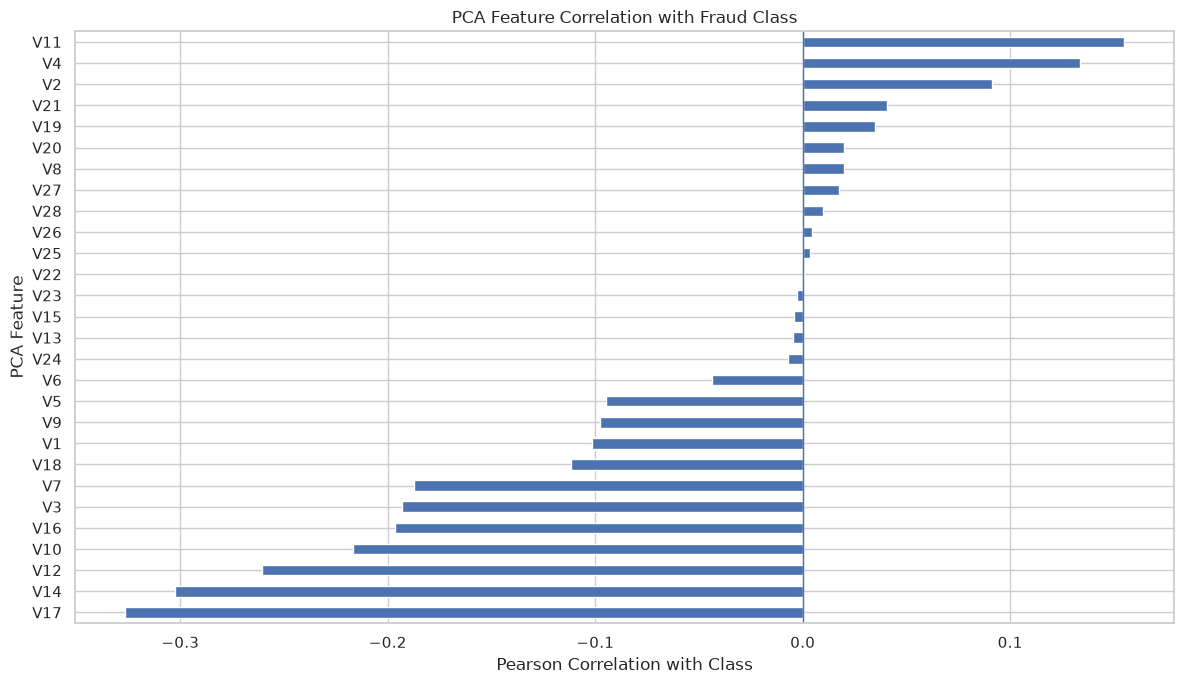

In [68]:
# Create a bar chart showing the Pearson correlation between each PCA feature and the target.
plt.figure(figsize=(12, 7))

# Plot the features ordered by absolute correlation with Class.
feature_class_correlation.sort_values().plot(
    kind="barh"
)

# Add a vertical reference line at zero correlation.
plt.axvline(0, linewidth=1)

# Add descriptive labels to the chart.
plt.title("PCA Feature Correlation with Fraud Class")
plt.xlabel("Pearson Correlation with Class")
plt.ylabel("PCA Feature")

# Adjust the layout to prevent labels from being cut off.
plt.tight_layout()

# Display the chart.
plt.show()

In [69]:
# Compare non-PCA numerical features with the target using training data only.
NON_PCA_FEATURES = [
    "Time",
    "Time_hours",
    "Time_hour",
    "Amount",
    "Amount_log"
]

non_pca_class_correlation = (
    feature_selection_train_df[NON_PCA_FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

non_pca_class_correlation


Time_hours   -0.011898
Time         -0.011898
Time_hour    -0.011888
Amount_log   -0.008228
Amount        0.005097
Name: Class, dtype: float64

In [70]:
# Define the numerical features to include in the final correlation analysis.
# Time_hours and Time_hour are excluded from this correlation matrix because they are derived from Time.
CORRELATION_FEATURES = (
    PCA_FEATURES
    + ["Amount", "Amount_log", "Time", "Class"]
)

# Calculate the Pearson correlation matrix for the selected features.
full_correlation = df[CORRELATION_FEATURES].corr()

# Display the correlation matrix.
full_correlation

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Amount_log,Time,Class
V1,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,7.388135e-17,2.125498e-16,2.053457e-16,-2.425603e-17,-5.020280e-16,3.547782e-16,7.212815e-17,-3.879840e-16,3.230206e-17,1.502024e-16,4.654551e-16,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.096375,0.117396,-0.101347
V2,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,-3.991394e-16,1.975426e-16,-9.568710e-17,6.295388e-16,-1.730566e-16,-4.995814e-17,1.177316e-17,-2.685296e-16,3.284605e-16,-7.118719e-18,2.506675e-16,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,-0.450317,-0.010593,0.091289
V3,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,1.156587e-15,1.576830e-15,6.310231e-16,2.807652e-16,4.739859e-16,9.068793e-16,8.299445e-16,7.614712e-16,1.509897e-16,3.463522e-16,-9.316409e-16,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.033913,-0.419618,-0.192961
V4,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,2.232685e-16,3.459380e-16,-5.625518e-16,1.303306e-16,2.282280e-16,1.377649e-16,-9.614528e-16,-2.699612e-16,-5.103644e-16,-3.980557e-16,-1.857247e-16,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,-0.004677,-0.105260,0.133447
V5,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,-5.202306e-16,7.203963e-16,7.412552e-16,5.886991e-16,6.565143e-16,-8.720275e-16,2.246261e-15,1.281914e-16,5.308590e-16,-1.450421e-16,-3.554057e-16,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.286189,0.173072,-0.094974
V6,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,5.932243e-17,1.980503e-15,2.375468e-16,-1.211182e-16,2.621312e-16,-1.531188e-15,2.623672e-18,2.015618e-16,1.223814e-16,-1.865597e-16,-1.858755e-16,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,0.163822,-0.063016,-0.043643
V7,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,-7.492834e-17,1.425248e-16,-3.536655e-18,1.266462e-17,2.607772e-16,-1.690540e-16,5.869302e-17,2.177192e-16,7.604126e-17,-1.881008e-16,9.379684e-16,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,0.095758,0.084714,-0.187257
V8,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,-2.801370e-16,2.487043e-16,1.839891e-16,-2.921856e-16,-8.599156e-16,4.127777e-16,-5.254741e-16,-2.269549e-16,-3.667974e-16,-3.875186e-16,2.033737e-16,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,-0.020690,-0.036949,0.019875
V9,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,-4.642274e-16,1.354680e-16,-1.079314e-15,2.251072e-15,3.784757e-15,-1.051167e-15,-1.214086e-15,1.113695e-15,4.993240e-16,-1.376135e-16,-2.343720e-16,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.080498,-0.008660,-0.097733
V10,7.388135e-17,-3.991394e-16,1.156587e-15,2.232685e-16,-5.202306e-16,5.932243e-17,-7.492834e-17,-2.8013

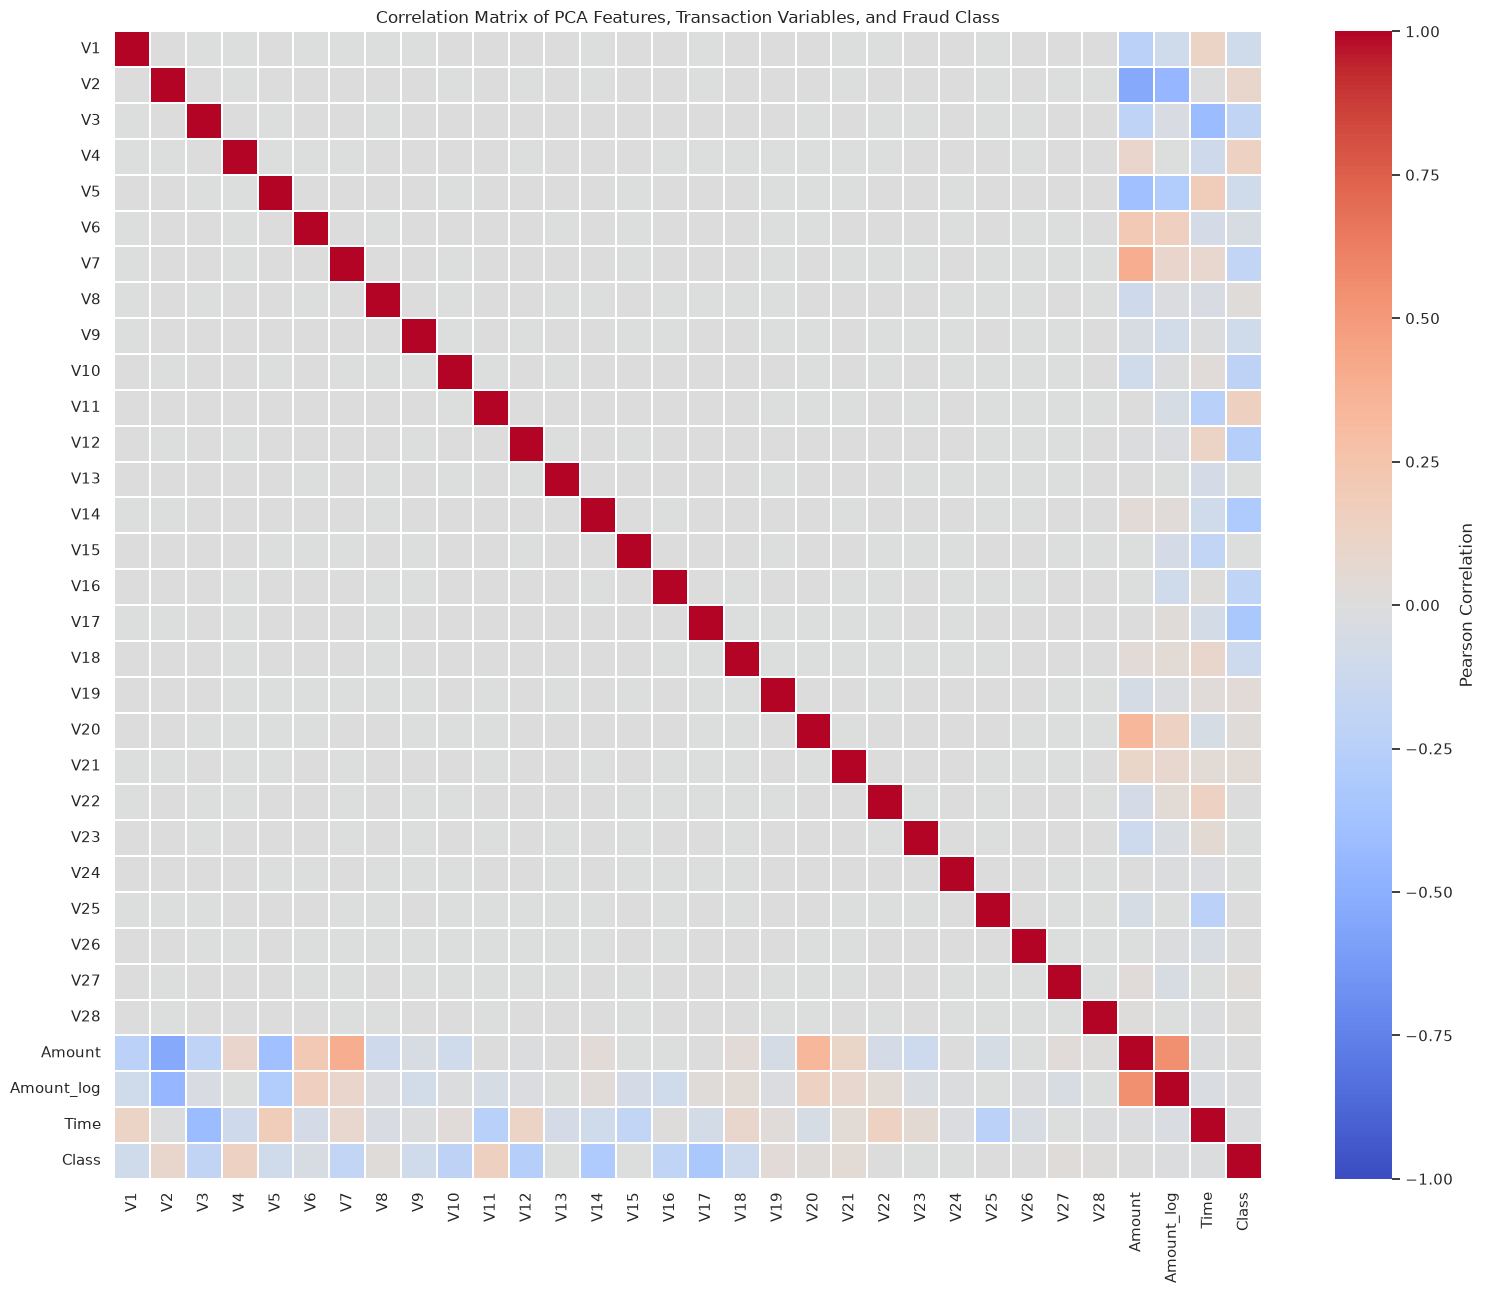

In [71]:
# Select the features used in the final correlation heatmap.
CORRELATION_FEATURES = (
    PCA_FEATURES
    + ["Amount", "Amount_log", "Time", "Class"]
)

# Calculate the Pearson correlation matrix.
correlation_matrix = df[CORRELATION_FEATURES].corr()

# Create the heatmap figure.
plt.figure(figsize=(16, 13))

# Display the correlation matrix as a heatmap.
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearson Correlation"}
)

# Add the chart title.
plt.title("Correlation Matrix of PCA Features, Transaction Variables, and Fraud Class")

# Adjust the layout.
plt.tight_layout()

# Display the heatmap.
plt.show()

#### Findings

The correlation analysis shows that the PCA-derived features (V1–V28) are effectively uncorrelated with each other, which is consistent with their construction as principal components.

Several PCA features show noticeable linear associations with the target variable. The strongest absolute correlations with fraud class are observed for V17, V14, V12, V10, V16, V3, and V7, while V11 and V4 show positive associations with the target.

In contrast, Amount and Time exhibit very weak linear correlations with the fraud class. This does not imply that these variables lack predictive information, since non-linear relationships, local temporal patterns, and interactions may not be captured by Pearson correlation.

Amount shows moderate linear relationships with several PCA components, while Amount and Amount_log are strongly related because Amount_log is a transformation of Amount.

The correlation analysis is exploratory and was not used to remove features. Predictive importance will be assessed later through model-based evaluation using appropriate validation procedures and fraud-specific metrics.

### 7.4 Outlier Analysis

In [72]:
# Define the numerical features that will be evaluated for potential outliers.
# We exclude the target variable and derived categorical time variables.
OUTLIER_FEATURES = PCA_FEATURES + ["Amount"]

# Calculate the first quartile (Q1) for each feature.
q1 = df[OUTLIER_FEATURES].quantile(0.25)

# Calculate the third quartile (Q3) for each feature.
q3 = df[OUTLIER_FEATURES].quantile(0.75)

# Calculate the interquartile range (IQR).
# IQR represents the range between the 25th and 75th percentiles.
iqr = q3 - q1

# Calculate the lower and upper IQR-based outlier boundaries.
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Display the boundaries for the first few features.
outlier_bounds = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound
})

outlier_bounds

,Q1,Q3,IQR,lower_bound,upper_bound
V1,-0.920373,1.315642,2.236015,-4.274396,4.669664
V2,-0.598550,0.803724,1.402274,-2.701961,2.907135
V3,-0.890365,1.027196,1.917560,-3.766705,3.903536
V4,-0.848640,0.743341,1.591981,-3.236612,3.131313
V5,-0.691597,0.611926,1.303524,-2.646882,2.567212
V6,-0.768296,0.398565,1.166861,-2.518586,2.148856
V7,-0.554076,0.570436,1.124512,-2.240844,2.257204
V8,-0.208630,0.327346,0.535976,-1.012593,1.131309
V9,-0.643098,0.597139,1.240237,-2.503452,2.457494
V10,-0.535426,0.453923,0.989349,-2.019449,1.937947


In [73]:
# Identify observations below the lower IQR boundary for each feature.
lower_outliers = df[OUTLIER_FEATURES].lt(lower_bound)

# Identify observations above the upper IQR boundary for each feature.
upper_outliers = df[OUTLIER_FEATURES].gt(upper_bound)

# Combine lower and upper outliers into one boolean matrix.
iqr_outliers = lower_outliers | upper_outliers

# Count the number of potential outliers for each feature.
outlier_count = iqr_outliers.sum()

# Calculate the percentage of observations classified as potential outliers.
outlier_percentage = (
    outlier_count / len(df) * 100
)

# Create a summary table with counts and percentages.
outlier_summary = pd.DataFrame({
    "outlier_count": outlier_count,
    "outlier_percentage": outlier_percentage
})

# Sort features by the number of potential outliers.
outlier_summary = outlier_summary.sort_values(
    "outlier_count",
    ascending=False
)

# Display the summary.
outlier_summary

,outlier_count,outlier_percentage
V27,39163,13.750715
Amount,31904,11.201972
V28,30342,10.653530
V20,27770,9.750463
V8,24134,8.473809
V6,22965,8.063355
V23,18541,6.510023
V12,15348,5.388912
V21,14497,5.090114
V14,14149,4.967926


In [74]:
# Calculate the number of potential IQR outliers within each target class.
outliers_by_class = (
    iqr_outliers
    .groupby(df["Class"])
    .sum()
    .T
)

# Rename the columns to make the target classes explicit.
outliers_by_class.columns = [
    "legitimate_outliers",
    "fraud_outliers"
]

# Calculate the total number of observations in each target class.
class_counts = df["Class"].value_counts().sort_index()

# Calculate the percentage of legitimate transactions classified
# as potential outliers for each feature.
outliers_by_class["legitimate_outlier_percentage"] = (
    outliers_by_class["legitimate_outliers"]
    / class_counts.loc[0]
    * 100
)

# Calculate the percentage of fraudulent transactions classified
# as potential outliers for each feature.
outliers_by_class["fraud_outlier_percentage"] = (
    outliers_by_class["fraud_outliers"]
    / class_counts.loc[1]
    * 100
)

# Sort the features by the percentage of fraud observations
# classified as potential outliers.
outliers_by_class = outliers_by_class.sort_values(
    "fraud_outlier_percentage",
    ascending=False
)

# Display the class-specific outlier analysis.
outliers_by_class

,legitimate_outliers,fraud_outliers,legitimate_outlier_percentage,fraud_outlier_percentage
V14,13719,430,4.825282,87.398374
V12,14939,409,5.254383,83.130081
V10,9097,399,3.199620,81.097561
V17,7023,397,2.470148,80.691057
V16,7833,351,2.755043,71.341463
V27,38819,344,13.653518,69.918699
V4,10830,318,3.809155,64.634146
V3,3051,312,1.073106,63.414634
V7,8647,301,3.041345,61.178862
V11,486,294,0.170937,59.756098


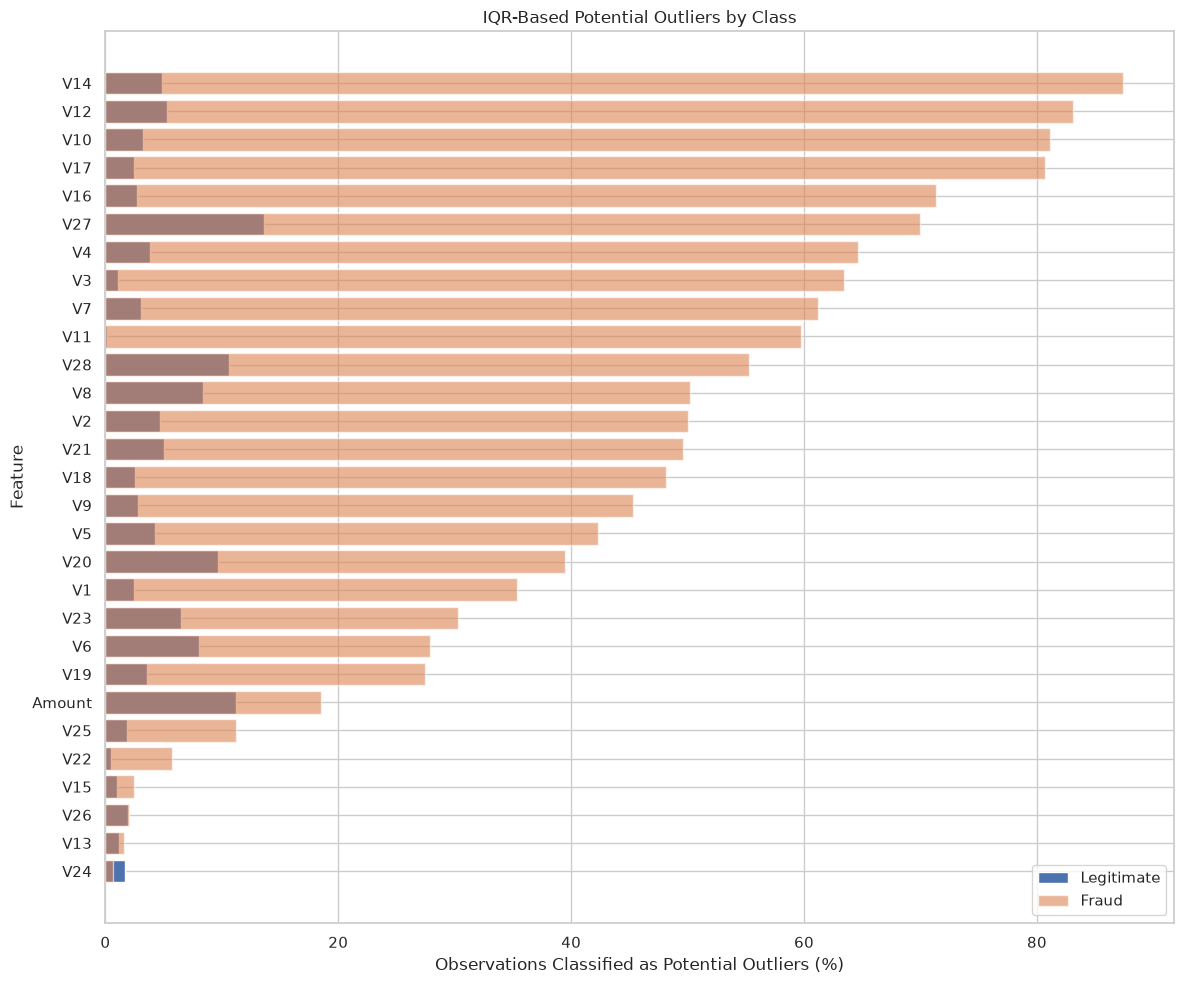

In [75]:
# Create a compact table containing the class-specific outlier percentages.
outlier_percentage_comparison = outliers_by_class[
    [
        "legitimate_outlier_percentage",
        "fraud_outlier_percentage"
    ]
].copy()

# Sort features by the percentage of fraudulent observations
# classified as potential outliers.
outlier_percentage_comparison = (
    outlier_percentage_comparison
    .sort_values("fraud_outlier_percentage", ascending=True)
)

# Create the horizontal bar chart.
plt.figure(figsize=(12, 10))

# Plot the percentage of legitimate observations classified as outliers.
plt.barh(
    outlier_percentage_comparison.index,
    outlier_percentage_comparison["legitimate_outlier_percentage"],
    label="Legitimate"
)

# Plot the percentage of fraudulent observations classified as outliers.
plt.barh(
    outlier_percentage_comparison.index,
    outlier_percentage_comparison["fraud_outlier_percentage"],
    alpha=0.6,
    label="Fraud"
)

# Add labels and title.
plt.title("IQR-Based Potential Outliers by Class")
plt.xlabel("Observations Classified as Potential Outliers (%)")
plt.ylabel("Feature")
plt.legend()

# Adjust the layout for readability.
plt.tight_layout()

# Display the chart.
plt.show()

In [76]:
# Count how many features classify each transaction as a potential IQR outlier.
# Each True value represents one feature where the transaction exceeds
# the corresponding IQR boundary.
df["iqr_outlier_count"] = iqr_outliers.sum(axis=1)

# Calculate descriptive statistics of the number of potential outlier features
# separately for legitimate and fraudulent transactions.
outlier_count_by_class = (
    df.groupby("Class")["iqr_outlier_count"]
    .describe()
)

# Display the distribution of the number of potential outlier features
# for each target class.
outlier_count_by_class

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,1.280777,2.134290,0.0,0.0,0.0,2.0,28.0
1,492.0,12.658537,6.400521,0.0,8.0,13.0,19.0,24.0


#### Findings

The IQR-based analysis identified a substantial number of potential outliers across several PCA-derived features and Amount. The number of observations classified as potential outliers varies considerably between features, reflecting the heterogeneous and heavy-tailed distributions observed earlier.

A strong difference was observed between legitimate and fraudulent transactions. For several PCA components, a much larger proportion of fraudulent transactions falls outside the IQR-based boundaries. For example, V14, V12, V10, and V17 classify more than 80% of fraudulent transactions as potential outliers, while the corresponding percentages for legitimate transactions are substantially lower.

The multivariate analysis also showed that fraudulent transactions tend to be extreme across multiple features simultaneously. The median number of potential outlier features was 13 for fraudulent transactions compared with 0 for legitimate transactions.

These findings indicate that extreme observations contain potentially important information for fraud detection. Therefore, observations identified as IQR-based outliers will not be removed, clipped, or winsorized at this stage.

The IQR-based outlier indicators were used only for exploratory analysis. They were calculated using the full dataset and will not be directly used as model features without appropriate recalculation using training data only.

No observations were removed as a result of the outlier analysis.

## 8. Feature Engineering

This section documents engineered feature decisions. The deterministic `Amount_log` transformation is introduced in the Amount EDA subsection because subsequent exploratory cells use it. Full-dataset Amount/Class analyses are descriptive only; label-informed candidate decisions for `Amount`, `Amount_log`, and `Time_hour` use the chronological training portion only.


### 8.1 Amount Feature Engineering

`Amount_log` is a deterministic transformation of `Amount`. Full-dataset amount summaries and Amount/Class comparisons are descriptive EDA only; the decision to retain `Amount` and `Amount_log` as modeling candidates is supported by the training-only analysis below.


In [77]:
# Define the original dataset columns that were present before feature engineering.
ORIGINAL_FEATURES = (
    PCA_FEATURES
    + ["Time", "Amount", "Class"]
)

# Identify columns that were created during the exploratory analysis.
DERIVED_FEATURES = [
    column
    for column in df.columns
    if column not in ORIGINAL_FEATURES
]

# Display the derived features currently present in the dataframe.
print("Derived features:")
print(DERIVED_FEATURES)

# Display the data type of each derived feature.
print("\nDerived feature data types:")
print(df[DERIVED_FEATURES].dtypes)

Derived features:
['Amount_log', 'Time_hours', 'Time_bin', 'Time_hour', 'iqr_outlier_count']

Derived feature data types:
Amount_log            float64
Time_hours            float64
Time_bin             category
Time_hour               int64
iqr_outlier_count       int64
dtype: object


#### 8.1.1 Full-Dataset Amount/Class Correlation — Descriptive Only

This correlation uses the full dataset for descriptive exploration only. It is not used to select or retain modeling features. The candidate decision below uses training data only.


In [78]:
# Descriptive full-dataset correlation only; not feature-selection evidence.
# Compare original and log-transformed transaction amounts with the target.
amount_class_correlation = df[
    ["Amount", "Amount_log", "Class"]
].corr()["Class"].sort_values(
    ascending=False
)

# Display the correlations with the target variable.
amount_class_correlation

Class         1.000000
Amount        0.005632
Amount_log   -0.008326
Name: Class, dtype: float64

#### 8.1.2 Training-Only Amount Candidate Analysis

The summaries and correlations below use `feature_selection_train_df`: the first 70% of chronologically ordered observations, matching the training boundary in Section 9.1. Differences in the training-only class-conditional Amount distributions support retaining `Amount` and its deterministic `Amount_log` transformation as candidate features for validation evaluation. Validation and test labels do not inform this decision. Candidate status does not assert that either feature improves model performance.


In [79]:
# Summarize Amount and Amount_log by target using training observations only.
amount_candidate_train_summary = (
    feature_selection_train_df.groupby(TARGET)
    .agg(
        transaction_count=("Amount", "count"),
        amount_mean=("Amount", "mean"),
        amount_median=("Amount", "median"),
        amount_log_mean=("Amount_log", "mean"),
        amount_log_median=("Amount_log", "median"),
    )
)

amount_candidate_train_correlation = (
    feature_selection_train_df[["Amount", "Amount_log", TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
)

print("Training-only class summaries:")
display(amount_candidate_train_summary)
print("\nTraining-only correlations with Class:")
display(amount_candidate_train_correlation)


Training-only class summaries:


,transaction_count,amount_mean,amount_median,amount_log_mean,amount_log_median
Class,,,,,
0,198980,89.715469,23.000,3.177184,3.178054
1,384,118.649453,11.855,2.866067,2.553106



Training-only correlations with Class:


Amount        0.005097
Amount_log   -0.008228
Name: Class, dtype: float64

### 8.2 Time Feature Engineering

In [80]:
# Compare original and engineered time features with the target using training data only.
time_feature_correlation = feature_selection_train_df[
    ["Time", "Time_hours", "Time_hour", TARGET]
].corr()[TARGET].sort_values()

time_feature_correlation


Time_hours   -0.011898
Time         -0.011898
Time_hour    -0.011888
Class         1.000000
Name: Class, dtype: float64



The original `Time` feature represents elapsed time since the first transaction. `Time_hours` is only a linear rescaling of `Time`, so it is not retained separately.

`Time_hour` is deterministically derived from elapsed time. Full-dataset temporal EDA is descriptive. Training-only hourly counts, rates, and correlations support keeping it as a candidate feature; validation and test labels do not influence this decision.

`Time_bin` remains exploratory and is not used for modeling.

### 8.3 Exploratory IQR Feature Analysis

In [81]:
# Calculate the Pearson correlation between the exploratory
# IQR outlier count and the fraud target.
iqr_count_class_correlation = df[
    ["iqr_outlier_count", "Class"]
].corr()["Class"]

# Display the correlation values.
iqr_count_class_correlation

iqr_outlier_count    0.21474
Class                1.00000
Name: Class, dtype: float64

### 8.4 Feature Engineering Conclusions

The feature engineering analysis evaluated transformations and derived variables for Amount, Time, and the exploratory IQR-based outlier analysis.

The deterministic `Amount_log` transformation reduces the right skew of `Amount`. Full-dataset Amount/Class plots and correlations are descriptive EDA only. Training-only class summaries and correlations support retaining both `Amount` and `Amount_log` as candidate modeling features for validation evaluation; validation and test labels do not inform this decision.

The `Time_hours` feature is a linear rescaling of `Time` and is not retained separately. `Time_hour` remains a candidate modeling feature because the training-only hourly fraud analysis supports evaluating it. Validation and test labels do not inform this decision.

`Time_bin` was created for exploratory temporal analysis and is not used as a modeling feature.

The exploratory `iqr_outlier_count` variable showed a positive correlation with the fraud target, but it was calculated using IQR boundaries derived from the full dataset. It remains exploratory and is not used as a modeling feature.

No other feature-engineering decisions are changed here. Final model performance is evaluated on the chronological validation set, with the test set reserved for final evaluation.


### 8.5 Modeling Feature Set

The feature set is defined before the explicit partition of `X` and `y`. Any label-informed decision to retain `Amount`, `Amount_log`, or `Time_hour` as a candidate is based only on the first 70% chronological training portion, using the same boundary as the later split. Validation and test labels do not inform these candidate decisions.


In [82]:
# Define the PCA-derived features used for modeling.
PCA_FEATURES = [f"V{i}" for i in range(1, 29)]

# Keep original and deterministic amount/time features. Candidate status for
# Amount, Amount_log, and Time_hour was assessed using training labels only.
ADDITIONAL_FEATURES = ["Amount", "Amount_log", "Time", "Time_hour"]
MODEL_FEATURES = PCA_FEATURES + ADDITIONAL_FEATURES
TARGET = "Class"

print("Number of modeling features:", len(MODEL_FEATURES))
print("Modeling features:", MODEL_FEATURES)
print("Target variable:", TARGET)


Number of modeling features: 32
Modeling features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_log', 'Time', 'Time_hour']
Target variable: Class


In [83]:
# Create the predictor matrix using only the selected modeling features.
X = df[MODEL_FEATURES].copy()

# Create the target vector using the fraud classification label.
y = df[TARGET].copy()

# Display the dimensions of the predictor matrix and target vector.
print("X shape:", X.shape)
print("y shape:", y.shape)

# Display the data types of the predictor variables.
print("\nFeature data types:")
print(X.dtypes)

# Display the target class distribution.
print("\nTarget distribution:")
print(y.value_counts())

# Display the target class proportions.
print("\nTarget proportions:")
print(y.value_counts(normalize=True))

X shape: (284807, 32)
y shape: (284807,)

Feature data types:
V1            float64
V2            float64
V3            float64
V4            float64
V5            float64
V6            float64
V7            float64
V8            float64
V9            float64
V10           float64
V11           float64
V12           float64
V13           float64
V14           float64
V15           float64
V16           float64
V17           float64
V18           float64
V19           float64
V20           float64
V21           float64
V22           float64
V23           float64
V24           float64
V25           float64
V26           float64
V27           float64
V28           float64
Amount        float64
Amount_log    float64
Time          float64
Time_hour       int64
dtype: object

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Target proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## 9. Chronological Train/Validation/Test Split

The data remains in chronological order and is partitioned into 70% training, 15% validation, and 15% test data. The training-only candidate analyses for `Amount`, `Amount_log`, and `Time_hour` use the same first-70% boundary as this split; validation and test labels do not inform feature selection.


### 9.1 Chronological 70/15/15 Split

In [84]:
# Check whether the dataset is ordered chronologically by the Time feature.
time_is_monotonic = df["Time"].is_monotonic_increasing

# Display the chronological ordering result.
print("Time is monotonically increasing:", time_is_monotonic)

# Display the first and last Time values.
print("\nFirst Time value:", df["Time"].iloc[0])
print("Last Time value:", df["Time"].iloc[-1])

# Calculate the relative position of each transaction in the dataset.
transaction_position = np.arange(len(df)) / len(df)

# Compare the number of fraudulent transactions across broad chronological segments.
df_temp = pd.DataFrame({
    "position": transaction_position,
    "Class": y.values
})

# Assign each transaction to one of five chronological segments.
df_temp["time_segment"] = pd.cut(
    df_temp["position"],
    bins=5,
    labels=["Segment 1", "Segment 2", "Segment 3", "Segment 4", "Segment 5"],
    include_lowest=True
)

# Calculate fraud counts and fraud rates for each chronological segment.
temporal_class_distribution = df_temp.groupby(
    "time_segment",
    observed=False
)["Class"].agg(
    fraud_count="sum",
    transaction_count="count",
    fraud_rate="mean"
)

# Display the chronological class distribution.
temporal_class_distribution

Time is monotonically increasing: True

First Time value: 0.0
Last Time value: 172792.0


,fraud_count,transaction_count,fraud_rate
time_segment,,,
Segment 1,157,56962,0.002756
Segment 2,84,56961,0.001475
Segment 3,119,56961,0.002089
Segment 4,57,56961,0.001001
Segment 5,75,56962,0.001317


In [85]:
# Define candidate chronological split proportions.
split_scenarios = {
    "70/15/15": (0.70, 0.15, 0.15),
    "80/10/10": (0.80, 0.10, 0.10),
    "70/20/10": (0.70, 0.20, 0.10)
}

# Store the number of observations in the dataset.
n_samples = len(df)

# Evaluate each candidate chronological split.
for scenario, (train_ratio, val_ratio, test_ratio) in split_scenarios.items():

    # Calculate the boundary positions for the train and validation sets.
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))

    # Extract the target labels for each chronological partition.
    train_classes = y.iloc[:train_end]
    val_classes = y.iloc[train_end:val_end]
    test_classes = y.iloc[val_end:]

    # Display the number of observations and fraud cases in each partition.
    print(f"\nScenario: {scenario}")
    print(
        f"Train: {len(train_classes):,} observations | "
        f"{train_classes.sum()} frauds | "
        f"{train_classes.mean():.6%} fraud rate"
    )
    print(
        f"Validation: {len(val_classes):,} observations | "
        f"{val_classes.sum()} frauds | "
        f"{val_classes.mean():.6%} fraud rate"
    )
    print(
        f"Test: {len(test_classes):,} observations | "
        f"{test_classes.sum()} frauds | "
        f"{test_classes.mean():.6%} fraud rate"
    )


Scenario: 70/15/15
Train: 199,364 observations | 384 frauds | 0.192613% fraud rate
Validation: 42,721 observations | 56 frauds | 0.131083% fraud rate
Test: 42,722 observations | 52 frauds | 0.121717% fraud rate

Scenario: 80/10/10
Train: 227,845 observations | 417 frauds | 0.183019% fraud rate
Validation: 28,481 observations | 53 frauds | 0.186089% fraud rate
Test: 28,481 observations | 22 frauds | 0.077244% fraud rate

Scenario: 70/20/10
Train: 199,364 observations | 384 frauds | 0.192613% fraud rate
Validation: 56,962 observations | 86 frauds | 0.150978% fraud rate
Test: 28,481 observations | 22 frauds | 0.077244% fraud rate


In [86]:
# Define the chronological split boundaries for train, validation, and test sets.
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)
assert train_end == train_end_for_feature_selection

# Split the feature matrix chronologically.
X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

# Split the target vector using the same chronological boundaries.
y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

# Display the dimensions of each dataset.
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (199364, 32) (199364,)
Validation shape: (42721, 32) (42721,)
Test shape: (42722, 32) (42722,)


In [87]:
# Combine the target distributions of the three chronological datasets.
split_class_distribution = pd.DataFrame({
    "Train": y_train.value_counts(),
    "Validation": y_val.value_counts(),
    "Test": y_test.value_counts()
}).fillna(0).astype(int)

# Display the number of legitimate and fraudulent transactions in each split.
print("Class counts:")
print(split_class_distribution)

# Calculate the fraud rate for each dataset.
split_fraud_rates = pd.Series({
    "Train": y_train.mean(),
    "Validation": y_val.mean(),
    "Test": y_test.mean()
})

# Display the fraud rate of each chronological split.
print("\nFraud rates:")
print(split_fraud_rates)

Class counts:
        Train  Validation   Test
Class                           
0      198980       42665  42670
1         384          56     52

Fraud rates:
Train         0.001926
Validation    0.001311
Test          0.001217
dtype: float64


### 9.2 Duplicate Analysis Across Splits

In [88]:
# Identify duplicated rows within the original dataset.
duplicate_mask = df.duplicated(keep=False)

# Store the original row indices that belong to duplicated groups.
duplicate_indices = df.index[duplicate_mask]

# Identify duplicated rows separately in each chronological split.
train_duplicate_count = X_train.duplicated(keep=False).sum()
val_duplicate_count = X_val.duplicated(keep=False).sum()
test_duplicate_count = X_test.duplicated(keep=False).sum()

# Display the number of duplicated feature rows within each split.
print("Duplicated feature rows within each split:")
print("Train:", train_duplicate_count)
print("Validation:", val_duplicate_count)
print("Test:", test_duplicate_count)

# Check whether identical feature rows exist across Train and Validation.
train_val_overlap = X_train.merge(
    X_val,
    how="inner"
).shape[0]

# Check whether identical feature rows exist across Train and Test.
train_test_overlap = X_train.merge(
    X_test,
    how="inner"
).shape[0]

# Check whether identical feature rows exist across Validation and Test.
val_test_overlap = X_val.merge(
    X_test,
    how="inner"
).shape[0]

# Display the cross-split overlap counts.
print("\nIdentical feature rows across splits:")
print("Train-Validation:", train_val_overlap)
print("Train-Test:", train_test_overlap)
print("Validation-Test:", val_test_overlap)

Duplicated feature rows within each split:
Train: 1256
Validation: 310
Test: 288



Identical feature rows across splits:
Train-Validation: 0
Train-Test: 0
Validation-Test: 0


#### Findings

The original dataset contains duplicated observations. After the chronological train/validation/test split, duplicated feature rows are present within each individual split.

However, no identical feature rows were found across the Train, Validation, and Test datasets.

Therefore, the identified duplicates do not create direct cross-split data leakage.

Because the dataset does not contain a unique transaction identifier that would allow us to determine whether duplicated rows represent data-entry duplication or distinct transactions with identical observed attributes, the duplicated observations will not be removed at this stage.

This preserves the original observations while avoiding an unsupported assumption that duplicated rows represent erroneous records.

### 9.3 Split Integrity and Feature Profile

In [89]:
# Calculate descriptive statistics for the modeling features in the training set.
train_feature_stats = X_train[MODEL_FEATURES].describe().T

# Calculate the numerical range of each feature.
train_feature_stats["range"] = (
    train_feature_stats["max"] - train_feature_stats["min"]
)

# Display the most relevant scale statistics.
train_feature_stats[
    ["mean", "std", "min", "max", "range"]
].sort_values(
    "std",
    ascending=False
)

,mean,std,min,max,range
Time,70444.416048,34502.988193,0.000000,132928.000000,132928.000000
Amount,89.771200,248.911638,0.000000,19656.530000,19656.530000
Time_hour,19.078424,9.576403,0.000000,36.000000,36.000000
V1,-0.105411,1.891043,-56.407510,2.454930,58.862440
Amount_log,3.176585,1.657930,0.000000,9.886216,9.886216
V2,0.003754,1.621781,-72.715728,22.057729,94.773457
V3,0.320783,1.447531,-33.680984,9.382558,43.063542
V4,0.075491,1.399229,-5.683171,16.875344,22.558515
V5,-0.112147,1.361533,-42.147898,34.801666,76.949564
V6,0.045975,1.311005,-26.160506,22.529298,48.689804


In [90]:
# Check for missing values in each chronological dataset.
missing_values = pd.DataFrame({
    "Train": X_train.isna().sum(),
    "Validation": X_val.isna().sum(),
    "Test": X_test.isna().sum()
})

# Display features with missing values.
print("Missing values:")
print(missing_values[missing_values.sum(axis=1) > 0])

# Check for infinite values in each chronological dataset.
infinite_values = pd.DataFrame({
    "Train": np.isinf(X_train).sum(),
    "Validation": np.isinf(X_val).sum(),
    "Test": np.isinf(X_test).sum()
})

# Display features with infinite values.
print("\nInfinite values:")
print(infinite_values[infinite_values.sum(axis=1) > 0])

# Display the total number of missing and infinite values.
print("\nTotal missing values:")
print(missing_values.to_numpy().sum())

print("\nTotal infinite values:")
print(infinite_values.to_numpy().sum())

Missing values:
Empty DataFrame
Columns: [Train, Validation, Test]
Index: []

Infinite values:
Empty DataFrame
Columns: [Train, Validation, Test]
Index: []

Total missing values:
0

Total infinite values:
0


## 10. Feature Scaling

### 10.1 Compare Scaler Behavior on Training Data

In [91]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Create a StandardScaler that will be fitted only on the training data.
standard_scaler = StandardScaler()

# Create a RobustScaler that will also be fitted only on the training data.
robust_scaler = RobustScaler()

# Fit both scalers exclusively on the training dataset.
standard_scaler.fit(X_train)
robust_scaler.fit(X_train)

# Transform the training data using each fitted scaler.
X_train_standard = standard_scaler.transform(X_train)
X_train_robust = robust_scaler.transform(X_train)

# Convert the transformed arrays back to DataFrames for easier inspection.
X_train_standard_df = pd.DataFrame(
    X_train_standard,
    columns=MODEL_FEATURES,
    index=X_train.index
)

X_train_robust_df = pd.DataFrame(
    X_train_robust,
    columns=MODEL_FEATURES,
    index=X_train.index
)

# Calculate the median and standard deviation after each transformation.
scaling_comparison = pd.DataFrame({
    "StandardScaler_median": X_train_standard_df.median(),
    "StandardScaler_std": X_train_standard_df.std(),
    "RobustScaler_median": X_train_robust_df.median(),
    "RobustScaler_std": X_train_robust_df.std()
})

# Display the scaling comparison.
scaling_comparison

,StandardScaler_median,StandardScaler_std,RobustScaler_median,RobustScaler_std
V1,0.007060,1.000003,0.000000e+00,0.868971
V2,0.047967,1.000003,5.083468e-18,1.188109
V3,0.118596,1.000003,0.000000e+00,0.928402
V4,0.000601,1.000003,-4.132568e-18,0.833326
V5,-0.042174,1.000003,0.000000e+00,1.090001
V6,-0.202259,1.000003,1.201855e-17,1.135370
V7,0.033106,1.000003,8.051578e-19,1.130747
V8,0.021577,1.000003,6.676314e-18,2.327965
V9,-0.072914,1.000003,0.000000e+00,0.880212
V10,-0.081405,1.000003,0.000000e+00,1.135752


### 10.2 Fit RobustScaler on Training Data and Transform All Splits

In [92]:
# Create a RobustScaler for models that are sensitive to feature scale.
robust_scaler = RobustScaler()

# Fit the scaler exclusively on the training data.
robust_scaler.fit(X_train)

# Transform the training data using parameters learned from the training set.
X_train_scaled = robust_scaler.transform(X_train)

# Transform the validation data using the same training-derived parameters.
X_val_scaled = robust_scaler.transform(X_val)

# Transform the test data using the same training-derived parameters.
X_test_scaled = robust_scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames while preserving feature names and indices.
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=MODEL_FEATURES,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=MODEL_FEATURES,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=MODEL_FEATURES,
    index=X_test.index
)

# Display the shapes of the scaled datasets.
print("Scaled Train shape:", X_train_scaled.shape)
print("Scaled Validation shape:", X_val_scaled.shape)
print("Scaled Test shape:", X_test_scaled.shape)

Scaled Train shape: (199364, 32)
Scaled Validation shape: (42721, 32)
Scaled Test shape: (42722, 32)


In [93]:
# Select representative features, including Time_hour, to validate the RobustScaler transformation.
validation_features = [
    "V1",
    "V14",
    "V28",
    "Amount",
    "Amount_log",
    "Time",
    "Time_hour"
]

# Calculate summary statistics for the selected scaled features in the training set.
scaled_train_summary = X_train_scaled[validation_features].describe().T[
    ["mean", "50%", "std", "min", "max"]
]

# Display the summary statistics of the scaled training features.
print("Scaled training feature summary:")
print(scaled_train_summary)

# Verify that the scaled datasets contain no missing values.
print("\nMissing values after scaling:")
print(
    X_train_scaled.isna().sum().sum(),
    X_val_scaled.isna().sum().sum(),
    X_test_scaled.isna().sum().sum()
)

# Verify that the scaled datasets contain no infinite values.
print("\nInfinite values after scaling:")
print(
    np.isinf(X_train_scaled).sum().sum(),
    np.isinf(X_val_scaled).sum().sum(),
    np.isinf(X_test_scaled).sum().sum()
)

Scaled training feature summary:
                mean           50%       std        min         max
V1         -0.006135  0.000000e+00  0.868971 -25.878053    1.170392
V14        -0.027853  0.000000e+00  1.104562 -21.923970   11.878859
V28        -0.138282  1.447240e-17  2.618346 -97.856292  282.232291
Amount      0.910558  0.000000e+00  3.394404  -0.313651  267.742125
Amount_log -0.000602  0.000000e+00  0.679051  -1.301661    2.747515
Time        0.068103  0.000000e+00  0.731464  -1.425320    1.392757
Time_hour   0.082956  0.000000e+00  0.736646  -1.384615    1.384615

Missing values after scaling:
0 0 0

Infinite values after scaling:
0 0 0


### 10.3 Feature Scaling Conclusions

The dataset was prepared using a chronological train/validation/test split to preserve the temporal structure of the transactions.

The final split contains 199,364 observations in the training set, 42,721 observations in the validation set, and 42,722 observations in the test set.

No missing or infinite values were identified in any of the modeling features.

A `RobustScaler` was fitted exclusively on the training data and subsequently used to transform the validation and test sets. This approach reduces the influence of extreme observations while avoiding information leakage from the validation or test sets.

The scaled representation will be used for models that are sensitive to feature magnitude, while tree-based models will use the original feature representation.

No observations were removed because of their extreme values or duplicated feature rows during preprocessing.

The resulting datasets are ready for the class imbalance analysis and subsequent model development.

## 11. Class Imbalance

### 11.1 Training Class Weights

In [94]:
# Calculate the number of legitimate and fraudulent observations in the training set.
train_class_counts = y_train.value_counts().sort_index()

# Calculate the percentage of each class in the training set.
train_class_percentages = y_train.value_counts(
    normalize=True
).sort_index() * 100

# Create a summary table of the training class distribution.
train_class_distribution = pd.DataFrame({
    "count": train_class_counts,
    "percentage": train_class_percentages
})

# Display the training class distribution.
print("Training class distribution:")
print(train_class_distribution)

# Calculate the ratio between legitimate and fraudulent transactions.
legitimate_count = train_class_counts.loc[0]
fraud_count = train_class_counts.loc[1]

# Display the class imbalance ratio.
print(
    f"\nLegitimate-to-fraud ratio: "
    f"{legitimate_count / fraud_count:.2f}:1"
)

Training class distribution:
        count  percentage
Class                    
0      198980   99.807387
1         384    0.192613

Legitimate-to-fraud ratio: 518.18:1


In [95]:
from sklearn.utils.class_weight import compute_class_weight

# Define the two target classes present in the training data.
classes = np.array([0, 1])

# Calculate balanced class weights using only the training labels.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Store the calculated weights in a dictionary for model configuration.
class_weight_dict = dict(zip(classes, class_weights))

# Display the calculated class weights.
print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(0.5009649210975977), np.int64(1): np.float64(259.5885416666667)}


### 11.2 Class Imbalance Conclusions

The training dataset is highly imbalanced, with 198,980 legitimate transactions and 384 fraudulent transactions, corresponding to an approximate legitimate-to-fraud ratio of 518:1.

This imbalance is an intrinsic characteristic of the dataset and will not be artificially corrected in the validation or test sets.

Balanced class weights were calculated from the training data as a reference. The resulting weights are approximately 0.501 for legitimate transactions and 259.589 for fraudulent transactions.

Class weighting will be evaluated as a model-specific strategy rather than being applied universally across all algorithms.

Resampling techniques, if evaluated, will be applied exclusively to the training data. The validation and test datasets will retain their original class distributions.

The effectiveness of class weighting and resampling will be assessed empirically using fraud-specific evaluation metrics, with PR-AUC as the primary metric and Precision, Recall, F1-score, ROC-AUC, and confusion matrices as complementary metrics.

No class-balancing transformation will be applied to the validation or test datasets.

## 12. Export Processed Data

### 12.1 Prepare and Save Processed Datasets

In [96]:
# Create a dictionary describing the processed datasets that will be used by later notebooks.
processed_datasets = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "X_train_scaled": X_train_scaled,
    "X_val_scaled": X_val_scaled,
    "X_test_scaled": X_test_scaled,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test
}

# Display the name, shape, and data type of each processed dataset object.
for dataset_name, dataset in processed_datasets.items():
    print(
        f"{dataset_name}: "
        f"shape={dataset.shape}, "
        f"type={type(dataset).__name__}"
    )

X_train: shape=(199364, 32), type=DataFrame
X_val: shape=(42721, 32), type=DataFrame
X_test: shape=(42722, 32), type=DataFrame
X_train_scaled: shape=(199364, 32), type=DataFrame
X_val_scaled: shape=(42721, 32), type=DataFrame
X_test_scaled: shape=(42722, 32), type=DataFrame
y_train: shape=(199364,), type=Series
y_val: shape=(42721,), type=Series
y_test: shape=(42722,), type=Series


In [97]:
# Use the project-root path resolved above so execution is independent of cwd.
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

existing_files = sorted(PROCESSED_DIR.iterdir())
print("Processed data directory:", PROCESSED_DIR)
print("Existing files:")
if existing_files:
    for file_path in existing_files:
        print(file_path.name)
else:
    print("No files found.")

Processed data directory: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed
Existing files:
X_test.parquet
X_test_scaled.parquet
X_train.parquet
X_train_scaled.parquet
X_val.parquet
X_val_scaled.parquet
robust_scaler.joblib
y_test.parquet
y_train.parquet
y_val.parquet


In [98]:
# Save the original feature datasets in Parquet format.
X_train.to_parquet(PROCESSED_DIR / "X_train.parquet")
X_val.to_parquet(PROCESSED_DIR / "X_val.parquet")
X_test.to_parquet(PROCESSED_DIR / "X_test.parquet")

# Save the scaled feature datasets in Parquet format.
X_train_scaled.to_parquet(PROCESSED_DIR / "X_train_scaled.parquet")
X_val_scaled.to_parquet(PROCESSED_DIR / "X_val_scaled.parquet")
X_test_scaled.to_parquet(PROCESSED_DIR / "X_test_scaled.parquet")

# Convert the target Series to DataFrames before saving them.
y_train.to_frame(name=TARGET).to_parquet(
    PROCESSED_DIR / "y_train.parquet"
)
y_val.to_frame(name=TARGET).to_parquet(
    PROCESSED_DIR / "y_val.parquet"
)
y_test.to_frame(name=TARGET).to_parquet(
    PROCESSED_DIR / "y_test.parquet"
)

# Display a confirmation message after saving all processed datasets.
print("All processed datasets were saved successfully.")

All processed datasets were saved successfully.


In [99]:
# Save the fitted RobustScaler for reproducible preprocessing.
from joblib import dump

# Define the output path for the fitted scaler.
SCALER_PATH = PROCESSED_DIR / "robust_scaler.joblib"

# Save the scaler that was fitted exclusively on the training data.
dump(robust_scaler, SCALER_PATH)

# Confirm that the scaler was saved successfully.
print(f"Scaler saved to: {SCALER_PATH}")
print(f"File exists: {SCALER_PATH.exists()}")

Scaler saved to: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed/robust_scaler.joblib
File exists: True


## 13. Final Integrity Checks

In [100]:
# Define the expected processed dataset filenames.
expected_files = [
    "X_train.parquet",
    "X_val.parquet",
    "X_test.parquet",
    "X_train_scaled.parquet",
    "X_val_scaled.parquet",
    "X_test_scaled.parquet",
    "y_train.parquet",
    "y_val.parquet",
    "y_test.parquet"
]

# Check whether every expected file exists in the processed data directory.
file_status = {
    filename: (PROCESSED_DIR / filename).exists()
    for filename in expected_files
}

# Display the existence status of each processed dataset.
print("File existence check:")
for filename, exists in file_status.items():
    print(f"{filename}: {exists}")

# Load the saved datasets back from disk to verify that they can be read successfully.
X_train_check = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_val_check = pd.read_parquet(PROCESSED_DIR / "X_val.parquet")
X_test_check = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")

X_train_scaled_check = pd.read_parquet(
    PROCESSED_DIR / "X_train_scaled.parquet"
)
X_val_scaled_check = pd.read_parquet(
    PROCESSED_DIR / "X_val_scaled.parquet"
)
X_test_scaled_check = pd.read_parquet(
    PROCESSED_DIR / "X_test_scaled.parquet"
)

y_train_check = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")
y_val_check = pd.read_parquet(PROCESSED_DIR / "y_val.parquet")
y_test_check = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")

# Display the shapes of the datasets loaded from disk.
print("\nLoaded dataset shapes:")
print("X_train:", X_train_check.shape)
print("X_val:", X_val_check.shape)
print("X_test:", X_test_check.shape)
print("X_train_scaled:", X_train_scaled_check.shape)
print("X_val_scaled:", X_val_scaled_check.shape)
print("X_test_scaled:", X_test_scaled_check.shape)
print("y_train:", y_train_check.shape)
print("y_val:", y_val_check.shape)
print("y_test:", y_test_check.shape)

File existence check:
X_train.parquet: True
X_val.parquet: True
X_test.parquet: True
X_train_scaled.parquet: True
X_val_scaled.parquet: True
X_test_scaled.parquet: True
y_train.parquet: True
y_val.parquet: True
y_test.parquet: True



Loaded dataset shapes:
X_train: (199364, 32)
X_val: (42721, 32)
X_test: (42722, 32)
X_train_scaled: (199364, 32)
X_val_scaled: (42721, 32)
X_test_scaled: (42722, 32)
y_train: (199364, 1)
y_val: (42721, 1)
y_test: (42722, 1)


In [101]:
# Verify that the saved training features are identical to the in-memory dataset.
print(
    "X_train identical:",
    X_train.equals(X_train_check)
)

# Verify that the saved validation features are identical to the in-memory dataset.
print(
    "X_val identical:",
    X_val.equals(X_val_check)
)

# Verify that the saved test features are identical to the in-memory dataset.
print(
    "X_test identical:",
    X_test.equals(X_test_check)
)

# Verify that the saved scaled training features are identical to the in-memory dataset.
print(
    "X_train_scaled identical:",
    X_train_scaled.equals(X_train_scaled_check)
)

# Verify that the saved scaled validation features are identical to the in-memory dataset.
print(
    "X_val_scaled identical:",
    X_val_scaled.equals(X_val_scaled_check)
)

# Verify that the saved scaled test features are identical to the in-memory dataset.
print(
    "X_test_scaled identical:",
    X_test_scaled.equals(X_test_scaled_check)
)

# Verify that the saved training target is identical to the in-memory target.
print(
    "y_train identical:",
    y_train.equals(y_train_check[TARGET])
)

# Verify that the saved validation target is identical to the in-memory target.
print(
    "y_val identical:",
    y_val.equals(y_val_check[TARGET])
)

# Verify that the saved test target is identical to the in-memory target.
print(
    "y_test identical:",
    y_test.equals(y_test_check[TARGET])
)

X_train identical: True
X_val identical: True
X_test identical: True
X_train_scaled identical: True
X_val_scaled identical: True
X_test_scaled identical: True
y_train identical: True
y_val identical: True
y_test identical: True


In [102]:
# Verify that all processed datasets exist and can be loaded successfully.
processed_files = [
    "X_train.parquet",
    "X_val.parquet",
    "X_test.parquet",
    "X_train_scaled.parquet",
    "X_val_scaled.parquet",
    "X_test_scaled.parquet",
    "y_train.parquet",
    "y_val.parquet",
    "y_test.parquet",
    "robust_scaler.joblib",
]

# Check whether every expected processed file exists.
file_status = {
    file_name: (PROCESSED_DIR / file_name).exists()
    for file_name in processed_files
}

# Display the existence status of each processed file.
for file_name, exists in file_status.items():
    print(f"{file_name}: {exists}")

# Confirm that all expected files are present.
print("\nAll processed files exist:", all(file_status.values()))

# Verify that the saved training features match the in-memory training features.
X_train_check = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_train_scaled_check = pd.read_parquet(
    PROCESSED_DIR / "X_train_scaled.parquet"
)
y_train_check = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")

print("\nX_train identical:", X_train.equals(X_train_check))
print("X_train_scaled identical:", X_train_scaled.equals(X_train_scaled_check))
print("y_train identical:", y_train.equals(y_train_check[TARGET]))

# Verify the expected dimensions of the training datasets.
print("\nX_train shape:", X_train_check.shape)
print("X_train_scaled shape:", X_train_scaled_check.shape)
print("y_train shape:", y_train_check.shape)

X_train.parquet: True
X_val.parquet: True
X_test.parquet: True
X_train_scaled.parquet: True
X_val_scaled.parquet: True
X_test_scaled.parquet: True
y_train.parquet: True
y_val.parquet: True
y_test.parquet: True
robust_scaler.joblib: True

All processed files exist: True



X_train identical: True


X_train_scaled identical: True
y_train identical: True

X_train shape: (199364, 32)
X_train_scaled shape: (199364, 32)
y_train shape: (199364, 1)


## 14. Phase I Conclusions

Phase I focused on understanding, preparing, and structuring the Credit Card Fraud Detection dataset for subsequent model development.

The original dataset contains 284,807 transactions and 31 original columns, including 28 PCA-derived features (`V1`–`V28`), `Time`, `Amount`, and the fraud target `Class`.

The dataset is extremely imbalanced, with 492 fraudulent transactions and 284,315 legitimate transactions. Fraudulent transactions represent approximately 0.17% of the complete dataset.

The exploratory analysis identified several relevant characteristics:

- The `Amount` feature is strongly right-skewed. The `log1p` transformation substantially reduced its skewness.
- The `Time` variable represents elapsed time and is chronologically ordered.
- Fraud rates vary across different temporal intervals. Full-dataset temporal plots are descriptive EDA only and are not used for feature selection.
- Several PCA-derived features exhibit substantial differences in distribution between legitimate and fraudulent transactions.
- Several PCA-derived features show noticeable linear associations with the fraud target.
- Many features contain extreme observations, and fraudulent transactions tend to be extreme across multiple features simultaneously.
- IQR-based outliers were therefore not removed or clipped.
- Duplicate observations were identified, but no identical feature rows were found across Train, Validation, and Test. The duplicates were therefore retained.

Feature engineering retained `Amount_log` and kept `Time_hour` as a candidate feature based on hourly fraud counts, rates, and correlations computed from the training prefix only.

`Time_hours` was excluded because it is a redundant linear transformation of `Time`.

`Time_bin` was retained only for exploratory temporal analysis and was not included as a modeling feature.

`iqr_outlier_count` was also retained only for exploratory analysis because it was calculated using full-dataset IQR boundaries and could introduce leakage if directly used as a modeling feature.

The final modeling dataset contains 32 predictor variables:

- `V1`–`V28`
- `Amount`
- `Amount_log`
- `Time`
- `Time_hour`

The dataset was divided chronologically into:

- 70% training data
- 15% validation data
- 15% test data

This resulted in 384 frauds in the training set, 56 frauds in the validation set, and 52 frauds in the test set.

No random stratification was applied because preserving the temporal ordering of transactions is important for the evaluation protocol.

For models sensitive to feature magnitude, a `RobustScaler` was fitted exclusively on the training data and then applied to the validation and test sets. Tree-based models will retain access to the original unscaled representation.

The class imbalance strategy was not applied to the validation or test datasets. Class weighting and resampling techniques will be evaluated later using the training data only.

The processed datasets were saved in Parquet format under `data/processed/` and verified by loading them back from disk.

The `Time_hour` feature-selection decision uses only the first 70% of chronological observations, which is the training partition in the following split. Validation and test labels do not influence this decision.

The prepared datasets are now ready for model development and evaluation in the next phase.